# [심화] 기술통계와 분포

_이 노트북은 LMS에서 내보냈습니다. 영상·퀴즈는 학습 참고용으로 마크다운으로 변환되었습니다._

# 📊 데이터의 생김새를 읽는다 — 기술통계와 분포 입문

## — 평균 하나로 끝내지 않는 법, 그리고 분포의 언어

---

## 📋 학습 목표

이 학습 노트북을 마치면 여러분은 다음을 할 수 있습니다.

1. 평균·분산·왜도·첨도의 의미와 각각이 답하지 못하는 한계를 사례로 설명할 수 있습니다.
2. 정규·이항·포아송·지수분포의 형태를 알아보고, 실무 데이터가 어느 분포에 가까운지 짚을 수 있습니다.
3. 베타분포가 **비율 데이터의 불확실성**을 표현하는 방식을 이해하고, `scipy.stats.beta`로 모양 변화를 그릴 수 있습니다.
4. Q-Q plot과 Shapiro-Wilk 검정으로 분포 적합성을 검증하고, 결과를 시각·수치 양쪽으로 읽을 수 있습니다.
5. 실무 변수의 분포를 진단해 이상치·다봉성·치우침(Skew)을 파악하고, **후속 분석 전략**으로 연결할 수 있습니다.
6. 통계 도구를 "공식"이 아닌 "데이터 특성에 맞는 선택"으로 보는 사고 습관을 들일 수 있습니다.

> 💡 위 목록을 천천히 읽고, 지금 할 수 있는 것과 아직 낯선 것을 마음속으로 표시해보세요. 노트북을 마친 뒤 다시 돌아와 비교하면 성장이 눈에 보일 거입니다.

## 📚 학습 목차

| Part      | 내용                                    | 핵심 질문                                     | ⏱ 예상 |
| --------- | --------------------------------------- | --------------------------------------------- | ------ |
| Part 0    | 오늘의 여정                             | 데이터의 "생김새"란 무엇을 가리키는가?        | 15분   |
| Part 1    | 기술통계 — 중심과 산포                  | 한 변수의 위치와 퍼짐을 어떤 숫자로 요약할까? | 35분   |
| Part 2    | 분포의 모양 — 왜도·첨도와 평균의 거짓말 | 같은 평균인데 분포가 전혀 다를 수 있을까?     | 35분   |
| Part 3    | 확률분포 4종 — 정규·이항·포아송·지수    | 실무 변수는 어떤 분포의 모양을 닮는가?        | 40분   |
| Part 4    | 베타분포 — 비율의 불확실성              | 적은 표본의 전환율 5/20을 어떻게 믿을까?      | 30분   |
| Part 5    | 적합성 검증 — Q-Q plot · Shapiro-Wilk   | "정규에 가깝다"를 어떻게 객관적으로 보일까?   | 35분   |
| 종합 실습 | 모두마켓 분포 진단 리포트               | 이 변수에 어떤 검정·도구가 적합한가?          | 30분   |
| 정리      | 핵심 요약 · 다음 시간                   | 분포를 봤다면, 다음에 던질 질문은?            | 5분    |

_⏱ 예상 시간은 참고용 안내입니다. 학습 속도는 사람마다 다릅니다 — 여러분의 속도로 가면 됩니다._

# Part 0. 오늘의 여정

## 🔁 지난 모듈 복습

지난 2주 동안 우리는 **분석할 깨끗한 데이터를 만드는 법**을 배웠습니다.

- **데이터 랭글링** — 결측·이상치를 다루고, 테이블을 병합하고, 문자열·날짜를 정제하고, 전처리 파이프라인까지 함수로 묶었습니다.
- **웹 스크래핑** — 외부에서 데이터를 가져오는 법까지 익혔습니다.

이제 우리 손에는 **분석할 준비가 끝난 데이터**가 있습니다. 그런데 막상 분석을 시작하려고 하면 첫 질문이 막막합니다.

> 이 변수는 어떻게 생겼지? 평균만 보면 될까? 정규분포인가? 어떤 검정·모델이 어울리지?

이 모든 질문은 결국 **"데이터의 생김새를 읽는 능력"** 으로 모입니다. 그게 오늘의 주제입니다.

## 🗺️ 오늘 배울 것

오늘은 "데이터가 어떤 모양인지" 읽는 법을 배웁니다. 평균이라는 한 숫자만 보던 시야에서 **분포 전체**를 보는 시야로 넓힙니다.

```text
[Part 1] 중심과 산포        →  한 변수의 위치와 퍼짐을 숫자로 요약
   ↓
[Part 2] 모양 — 왜도·첨도   →  같은 평균에도 모양은 다를 수 있다
   ↓
[Part 3] 분포 4종            →  정규·이항·포아송·지수 — 실무 변수의 닮은꼴
   ↓
[Part 4] 베타분포            →  비율 데이터의 불확실성을 표현하는 도구
   ↓
[Part 5] 적합성 검증         →  Q-Q plot · Shapiro-Wilk으로 객관적 진단
   ↓
[종합 실습] 모두마켓 변수 분포 진단 리포트
```

## ⚙️ 환경 설정과 실습 데이터

> ⚠️ **주의:** 코드 셀은 반드시 위에서부터 순서대로 실행하세요. 중간부터 실행하면 이전 셀의 변수를 찾지 못해 오류가 납니다.

In [1]:
# ─────────────────────────────────────────────
# [C1] 환경 준비 — 라이브러리 + 한글 폰트 + 시드 고정
# ─────────────────────────────────────────────
# 필요 시 아래 주석을 해제해 설치하세요.
# !pip install numpy pandas scipy statsmodels matplotlib seaborn -q

import platform
import warnings

import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

# 재현성: 같은 난수를 항상 같게 만듭니다.
np.random.seed(42)

# 한글 폰트 설정
system = platform.system()
if system == "Darwin":
    plt.rcParams["font.family"] = "AppleGothic"
elif system == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"
else:
    plt.rcParams["font.family"] = "DejaVu Sans"

plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.figsize"] = (10, 5)
sns.set_style("whitegrid")

print("준비 완료!")
print("numpy :", np.__version__)
print("pandas:", pd.__version__)
print("scipy :", stats.__name__)

준비 완료!
numpy : 2.4.6
pandas: 3.0.3
scipy : scipy.stats


## 🎬 오늘의 무대 — 분석가의 책상에 놓인 네 개의 데이터

여러분은 데이터 분석가입니다. 오늘 아침, 성격이 전혀 다른 **네 개의 실제 데이터셋**이 책상에 놓였습니다.

> - 🍽️ `tips` — 식당 영수증의 **결제 금액**
> - 🚢 `titanic` — 승객의 **운임(fare)** 과 **나이(age)**
> - 🐧 `penguins` — 펭귄의 **종(species)** 과 **체중(body mass)**
> - 🌐 `web_logs` — 웹사이트 **접속 로그**(시각·응답)

동료가 묻습니다.

> "각 데이터의 평균만 보고하면 될까요? 어떤 변수에 어떤 검정·모델이 어울리는지도 알고 싶어요."

이 질문에 답하려면 **각 변수가 어떤 모양(분포)인지** 먼저 봐야 합니다. 평균 하나로는 부족하거든요. 그래서 오늘은 분포를 _보는 눈_ 을 키웁니다.

> 🎯 **오늘의 핵심**
> **기술통계량은 시각화와 짝을 이뤄야 한다.** "평균만 보면 분포에 속습니다." 모양과 닮은꼴을 알아야 도구를 고를 수 있습니다.

아래 셀을 실행하면 오늘 쓸 네 데이터셋이 로드됩니다. `tips`·`titanic`·`penguins`는 **seaborn 내장 데이터셋**으로 인터넷에서 자동으로 받아오고, `web_logs`는 공개 데이터가 아니라 **같은 통계적 성질을 재현하도록 합성 생성**합니다(시드 고정). 각 데이터는 _서로 다른 분포_(우편향·다봉·포아송 등)를 실제로 품고 있어, 교과서가 아니라 *진짜 데이터*로 분포를 진단합니다.

In [2]:
# ─────────────────────────────────────────────
# [C2] 실습 데이터 로드 — 인터넷에서 받아오기
#   · tips / titanic / penguins : seaborn 내장 데이터셋
#       (seaborn-data GitHub 저장소에서 자동 다운로드 → 인터넷 필요)
#   · web_logs : 공개 데이터셋이 아니므로, 같은 통계적 성질
#       (포아송 방문자 · 이진 성공/실패)을 재현하도록 시드 고정 합성 생성
# ─────────────────────────────────────────────

# ── (1) seaborn 내장 실데이터 3종 ──
tips     = sns.load_dataset("tips")        # 식당 영수증(결제 금액·팁)
titanic  = sns.load_dataset("titanic")     # 타이타닉 승객(운임·나이)
penguins = sns.load_dataset("penguins")    # 펭귄 신체 측정(종·체중)

# ── (2) 웹 접속 로그(합성) ──
# 실제 로그 파일 대신, 분포 진단에 필요한 성질을 그대로 갖도록 생성합니다.
#   - 일별 '고유 방문자 수'가 포아송을 닮도록 (포아송 후보)
#   - status_code 의 성공(200) 비율이 일정하도록 (베타 후보)
rng = np.random.default_rng(42)            # 재현성: 시드 고정
n_days = 180
start  = pd.Timestamp("2024-01-01")

# 일별 고유 방문자 수를 먼저 포아송으로 확정 (var ≈ mean 성질 유지)
day_visitors = rng.poisson(150, size=n_days)

_frames = []
for d in range(n_days):
    n_vis    = int(day_visitors[d])                    # 그날 고유 방문자 수 → 포아송
    reqs_per = rng.integers(1, 14, size=n_vis)         # 방문자당 요청 수
    total    = int(reqs_per.sum())
    user_ids = np.repeat(np.arange(n_vis) + d * 10_000, reqs_per)   # 날짜별 고유 id
    secs     = rng.integers(0, 86_400, size=total)                  # 하루 중 초 단위 시각
    ts       = start + pd.Timedelta(days=d) + pd.to_timedelta(secs, unit="s")
    status   = np.where(rng.random(total) < 0.93, 200,             # 성공률 ≈ 0.93
                        rng.choice([404, 500, 503], size=total))
    resp     = rng.exponential(120, size=total)                    # 응답시간(ms) → 지수 형태
    _frames.append(pd.DataFrame({"ts": ts, "user_id": user_ids,
                                 "status_code": status, "response_ms": resp}))

web = (pd.concat(_frames, ignore_index=True)
         .sort_values("ts")
         .reset_index(drop=True))
web["date"] = web["ts"].dt.date

# 일별 '고유 방문자 수' — 독립적으로 드물게 일어나는 사건의 합 → 포아송 후보
visitors = web.groupby("date")["user_id"].nunique()

print("로드 완료 ✓  (tips·titanic·penguins: seaborn 인터넷 다운로드 / web: 합성)")
print(f"  tips     {tips.shape}  · 식당 영수증")
print(f"  titanic  {titanic.shape} · 승객 (운임·나이)")
print(f"  penguins {penguins.shape}   · 펭귄 (종·체중)")
print(f"  web      {web.shape} · 웹 로그 → 일별 방문자 {len(visitors)}일치")
titanic.head()

로드 완료 ✓  (tips·titanic·penguins: seaborn 인터넷 다운로드 / web: 합성)
  tips     (244, 7)  · 식당 영수증
  titanic  (891, 15) · 승객 (운임·나이)
  penguins (344, 7)   · 펭귄 (종·체중)
  web      (188022, 5) · 웹 로그 → 일별 방문자 180일치


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


> **읽는 법:** 네 개의 실제 데이터셋을 로드했습니다. 각 데이터는 크기도 성격도 다릅니다 — `tips`(244행)는 식당 영수증, `titanic`(891행)은 승객, `penguins`(344행)는 펭귄, `web`은 웹 로그 표본입니다. 오늘 우리는 이 데이터들의 변수가 *어떤 모양*인지 진단합니다. 평균만 보면 결코 알 수 없는 차이가 있습니다.

## 📖 핵심 용어 사전

오늘 본문에서 등장할 기호를 미리 정리합니다. 모르는 기호가 보일 때 이 표로 돌아오세요.

| 기호                        | 읽는 법            | 의미                                                            |
| --------------------------- | ------------------ | --------------------------------------------------------------- |
| $\mu$                       | 뮤(mu)             | **모평균** — 모집단(전체)의 평균. 우리가 알고 싶지만 보통 모름. |
| $\bar{x}$                   | 엑스 바(x-bar)     | **표본평균** — 우리가 가진 표본의 평균. $\mu$의 추정치.         |
| $\sigma^2,\ \sigma$         | 시그마 제곱·시그마 | **모분산·모표준편차** — 모집단의 퍼짐 정도.                     |
| $s^2,\ s$                   | 에스 제곱·에스     | **표본분산·표본표준편차** — 표본의 퍼짐. $\sigma^2$의 추정치.   |
| $n$                         | 엔                 | **표본 크기** — 관측한 데이터 개수.                             |
| $N(\mu, \sigma^2)$          | 노멀               | **정규분포** — 평균 $\mu$, 분산 $\sigma^2$인 정규분포.          |
| 왜도(Skewness)              | 스큐               | 분포의 **비대칭** 정도. 0이면 좌우 대칭.                        |
| 첨도(Kurtosis)              | 커토시스           | 분포가 평균 근처에 얼마나 **뾰족·납작**한가.                    |
| $\alpha,\ \beta$ (베타분포) | 알파·베타          | 베타분포의 **형태 모수**(Shape Parameter). 비율의 모양을 결정.  |
| $p$-value                   | 피 밸류            | 검정에서 자주 쓰는 확률 (Part 5에서 등장).                      |

> 💡 **개념 연결:** 모수(Parameter, $\mu$·$\sigma$ 등)는 _모집단 전체의 진짜 값_, 통계량(statistic, $\bar{x}$·$s$ 등)은 *우리가 표본에서 계산한 값*입니다. 우리는 항상 *통계량으로 모수를 추정*합니다 — 이 출발점이 이후부터의 **추론통계(Inferential Statistics)** 의 핵심입니다.

# Part 1. 기술통계 — 중심과 산포

분포의 모양을 한 번에 다 묘사하기는 어렵습니다. 그래서 통계는 분포를 **세 차원의 숫자**로 요약합니다.

1. **중심(Center)** — 데이터가 대략 어디 있는가?
2. **산포(Spread)** — 얼마나 퍼져 있는가?
3. **모양(shape)** — 좌우 대칭인가, 한쪽으로 치우쳤는가?

오늘 Part 1은 ①중심과 ②산포를 다루고, ③모양은 다음 Part에서 다룹니다.

> ❓ **이 파트에서 답할 질문:**한 변수의 "위치"와 "퍼짐"을 어떤 숫자로 요약해야 할까?

## 💡 쉽게 말하면 —한 줄에 점을 찍는다고 상상하기

```text
변수 값 7개를 수평선에 점으로 찍어봅시다.
        ●  ●●●●  ●           ●
─────────|──|──────────────|──
        20  35              90

(a) 중심  → 점들이 어디쯤 모여 있나? (평균? 중앙값?)
(b) 산포  → 점들이 얼마나 퍼져 있나? (좌우 폭은?)
```

중심을 표현하는 통계량은 **평균(Mean)·중앙값(Median)·최빈값(Mode)** 세 가지가 가장 흔합니다. 산포는 **분산·표준편차·IQR(사분위 범위)·범위** 같은 도구로 표현합니다.

## 중심·산포를 수식으로 (기호 풀이 포함)

### 평균(Mean)과 표본평균($\bar{x}$)

$$\bar{x} = \frac{1}{n} \sum_{i=1}^{n} x_i$$

| 기호             | 의미                                             |
| ---------------- | ------------------------------------------------ |
| $\bar{x}$        | 표본평균 (우리가 가진 데이터의 평균)             |
| $n$              | 표본 크기 (관측 개수)                            |
| $x_i$            | $i$번째 관측값                                   |
| $\sum_{i=1}^{n}$ | "$i=1$부터 $n$까지 모두 더하라"는 시그마 합 기호 |

요약하면 평균은 _"모든 값을 더해 개수로 나눈 것"_ 입니다. 일상 언어와 같습니다.

### 표본분산($s^2$)과 표본표준편차($s$)

$$s^2 = \frac{1}{n-1} \sum_{i=1}^{n} (x_i - \bar{x})^2 \qquad s = \sqrt{s^2}$$

| 기호                | 의미                                                                                             |
| ------------------- | ------------------------------------------------------------------------------------------------ |
| $s^2$               | 표본분산                                                                                         |
| $s$                 | 표본표준편차 (분산의 제곱근)                                                                     |
| $x_i - \bar{x}$     | 각 관측값이 평균에서 떨어진 거리(편차)                                                           |
| $(x_i - \bar{x})^2$ | 편차를 제곱(부호를 없애고 큰 차이는 더 강조)                                                     |
| $n - 1$             | **자유도(Degrees of Freedom)** — 표본분산은 $n$ 대신 $n-1$로 나눕니다(불편추정량을 만들기 위해). |

분산의 단위는 *원래 단위의 제곱*이라 직관적이지 않습니다. 그래서 제곱근을 씌운 **표준편차**를 더 자주 씁니다. 평균과 단위가 같아서 _"평균 ± 표준편차"_ 형태로 해석이 쉽습니다.

### 중앙값(Median)과 IQR

중앙값은 데이터를 정렬했을 때 **한가운데 값**입니다. **이상치에 강건(Robust)** 합니다.

**IQR(Interquartile Range)** 은 Q3(75%) - Q1(25%)로, 중앙 50%의 폭입니다. 이상치에 흔들리지 않는 산포 측정값입니다.

> 💡 **개념 연결:** 지난 모듈의 IQR 이상치 탐지와 Robust Scaler가 바로 이 IQR을 분모로 썼습니다. 같은 도구가 분포 진단에서는 _산포의 robust 측정값_ 으로 등장합니다.

In [3]:
# [C3] 예제 1.1: 평균·중앙값·표준편차·IQR — pandas로 한 번에
fare = titanic["fare"].dropna()
print(f"타이타닉 운임(fare) 표본 크기 n = {len(fare)}")
print(f"표본평균 x̄ = {fare.mean():,.2f}")
print(f"중앙값   = {fare.median():,.2f}")
print(f"표본표준편차 s = {fare.std():,.2f}")
print(f"Q1 = {fare.quantile(0.25):,.2f}")
print(f"Q3 = {fare.quantile(0.75):,.2f}")
print(f"IQR = Q3 - Q1 = {fare.quantile(0.75) - fare.quantile(0.25):,.2f}")
print(f"최솟값 = {fare.min():,.2f}, 최댓값 = {fare.max():,.2f}")

타이타닉 운임(fare) 표본 크기 n = 891
표본평균 x̄ = 32.20
중앙값   = 14.45
표본표준편차 s = 49.69
Q1 = 7.91
Q3 = 31.00
IQR = Q3 - Q1 = 23.09
최솟값 = 0.00, 최댓값 = 512.33


> **읽는 법:** 평균(약 32)과 중앙값(약 14.5)이 _두 배 넘게_ 차이 납니다! 비싼 1등실 운임 몇 건이 평균을 끌어올려 분포가 강하게 치우쳐 있습니다. 어느 쪽이 "대표 운임"일까요? 대부분 승객에겐 **중앙값**이 더 현실적입니다 — 그래서 우리는 평균·중앙값을 **둘 다** 봅니다. 이 차이가 곧 Part 2에서 다룰 **왜도**의 단서입니다.

In [4]:
# [C4] 예제 1.2: describe() — 한 번에 보기 (운임 vs 나이)
titanic[["fare", "age"]].describe().round(2)

,fare,age
count,891.00,714.00
mean,32.20,29.70
std,49.69,14.53
min,0.00,0.42
25%,7.91,20.12
50%,14.45,28.00
75%,31.00,38.00
max,512.33,80.00


> **읽는 법:** `describe()`는 개수·평균·표준편차·최솟값·사분위·최댓값을 한 표로 보여줍니다. 분석가가 처음 데이터를 받았을 때 가장 먼저 보는 표 중 하나입니다.
>
> 두 변수를 _나란히_ 비교해보세요. `fare`(운임)는 평균과 중앙값(50%) 차이가 크고 표준편차도 큽니다 — 강하게 치우쳤다는 신호. 반면 `age`(나이)는 평균과 중앙값이 가깝습니다 — 대칭에 가깝다는 뜻입니다. 또 `count`를 보면 `age`가 `fare`보다 적습니다(나이에 결측이 있음).

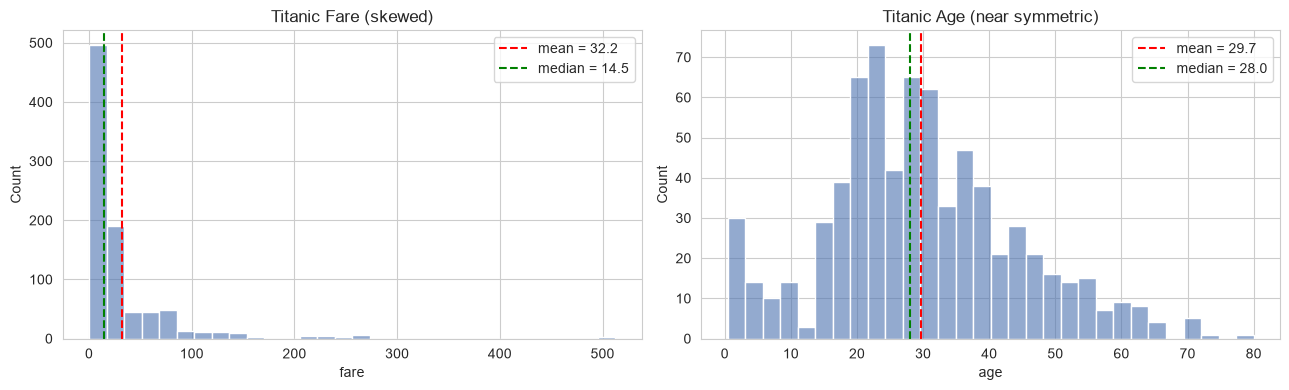

In [5]:
# [C5] 예제 1.3: 평균과 중앙값을 그림에 함께 — 분포가 한쪽으로 치우치면 두 값이 갈라진다
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, col, title in zip(axes,
                          ["fare", "age"],
                          ["Titanic Fare (skewed)", "Titanic Age (near symmetric)"]):
    s = titanic[col].dropna()
    sns.histplot(s, bins=30, ax=ax, color="#4C72B0", alpha=0.6)
    ax.axvline(s.mean(),   color="red",   linestyle="--", label=f"mean = {s.mean():,.1f}")
    ax.axvline(s.median(), color="green", linestyle="--", label=f"median = {s.median():,.1f}")
    ax.set_title(title)
    ax.legend()

plt.tight_layout(); plt.show()

> **읽는 법:** 왼쪽(운임) — 빨간 평균선이 초록 중앙값선보다 한참 **오른쪽**에 있습니다. 비싼 운임 몇 건이 평균을 끌어올린 것입니다. 오른쪽(나이) — 두 선이 거의 겹칩니다. _대칭에 가까운_ 분포의 특징입니다.

## ⚠️ 오늘의 흔한 오해 모음

> ❗ **"평균만 보면 분포의 절반은 못 본다."**
> 같은 평균이어도 산포(표준편차)와 모양(왜도)이 전혀 다를 수 있습니다. 그래서 평균은 _항상_ 산포·모양과 함께 보고합니다.

> ❗ **표준편차와 표준오차(Standard Error)는 다르다.**
> 표준편차 $s$는 _값이 얼마나 퍼졌나_, 표준오차 $s / \sqrt{n}$은 *평균 추정치가 얼마나 흔들리나*입니다. 검정·신뢰구간에서 둘을 자주 헷갈리니 미리 구분해 두세요.

## 📊 데이터로 확인해 봅시다

- **변수의 첫 진단:** `describe()` 한 줄로 평균·중앙값·표준편차·IQR을 한꺼번에 받습니다.
- **이상치 신호:** 평균과 중앙값이 크게 벌어지면 _치우침·이상치_ 의심 — Part 2로 확인.
- **단위 비교:** 두 변수의 산포를 비교할 때 단위가 다르면 **변동계수(CV = $s / \bar{x}$)** 를 씁니다 (다른 단위끼리도 비교 가능).

> 📌 **다른 산업에서는?** 금융은 자산 수익률 분포에서 평균(기대수익)과 표준편차(변동성)를 **함께** 봅니다 — 평균만으로는 위험을 못 보니까요. 헬스케어는 환자 검사 수치의 중앙값·IQR을 자주 씁니다(소수의 극단값에 흔들리지 않게). 제조 공정에서는 표준편차가 곧 **품질의 안정성**입니다.

## ⌨️ 백문이 불여일타! (1)

```
[문제]
1) visitors(일별 고유 방문자 수)의 평균·중앙값·표준편차·IQR을 출력해보세요.
2) titanic["fare"]와 tips["total_bill"] 둘 다 "금액"인데, 두 변수의 변동계수(CV)를 비교해보세요.
   어떤 변수가 상대적으로 더 흔들립니까?
3) 같은 평균인데 표준편차가 큰 두 데이터가 있다면, 비즈니스 관점에서 어느 쪽이 예측하기
   어렵다고 할 수 있을지 판단과 근거를 주석으로 정리해보세요. -> 분산큰게어려움, 예측이 어려울거니까
```

In [13]:
tips.head(4)

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2


In [17]:
# [C6] ⌨️ 백문이 불여일타! (1) — visitors 요약 통계와 두 금액 변수의 CV 비교
daily_counts=tips.groupby('day').size()
mean_val = daily_counts.mean()
median_val = daily_counts.median()
std_val = daily_counts.std()

q1 = daily_counts.quantile(0.25)
q3 = daily_counts.quantile(0.75)
iqr_val = q3 - q1

print("평균:", mean_val)
print("중앙값:", median_val)
print("표준편차:", std_val)
print("IQR:", iqr_val)
# 여기에 코드를 작성하세요

평균: 61.0
중앙값: 69.0
표준편차: 29.81051268708183
IQR: 27.5


In [ ]:
fare_mean = titanic['fare'].mean()
fare_std = titanic['fare'].std()
fare_cv = fare_std / fare_mean

bill_mean = tips['total_bill'].mean()
bill_std = tips['total_bill'].std()
bill_cv = bill_std / bill_mean

print("fare 평균:", fare_mean, "표준편차:", fare_std, "CV:", fare_cv)
print("total_bill 평균:", bill_mean, "표준편차:", bill_std, "CV:", bill_cv)

# fare(titanic 탑승 요금)가 total_bill보다 상대적으로 훨씬 더 흔들려요(변동성이 큼).

fare 평균: 32.204207968574636 표준편차: 49.6934285971809 CV: 1.5430725278408497
total_bill 평균: 19.78594262295082 표준편차: 8.902411954856856 CV: 0.44993620594706724


<details>
<summary>(클릭) 💡 힌트</summary>

- 평균·중앙값·표준편차는 `mean()`·`median()`·`std()`로, IQR은 `quantile(0.75)`에서 `quantile(0.25)`를 빼면 구할 수 있습니다 — [C3]에서 본 그 패턴입니다.
- 변동계수(CV)는 `std / mean`입니다 — 단위·규모가 다른 변수끼리 "평균 대비 흔들림"을 비교할 때 씁니다.
- 3번은 코드가 필요 없습니다 — 표준편차가 크다는 것이 내일의 값을 맞히는 일에 어떤 의미인지 떠올려보세요.

</details>

## 🚦 짚고 넘어가기

다음 질문에 답할 수 있으면 다음 Part로 넘어가세요. 틀려도 괜찮습니다.

1. 평균과 중앙값이 크게 다르다는 사실은 분포에 대해 무엇을 시사하나요?
2. 분산과 표준편차 중 _해석이 쉬운_ 쪽은 어느 쪽이며, 그 이유는?
3. 표본분산을 계산할 때 $n$이 아니라 $n-1$로 나누는 이유는 한 단어로 무엇인가요? (힌트: ㅈㅇㄷ)

> 💡 **다음 Part 예고:** 중심과 산포를 봤지만, "분포가 한쪽으로 얼마나 치우쳤나"·"가운데가 얼마나 뾰족한가"는 아직 못 봤습니다. 다음 Part에서 분포의 **모양**을 숫자로 표현하는 왜도·첨도와, *평균이 우리를 속이는 두 가지 함정*을 만납니다.

# Part 2. 분포의 모양 — 왜도·첨도와 평균의 거짓말

Part 1에서 같은 평균이라도 *산포*가 다를 수 있다는 걸 봤습니다. 더 미묘한 차이가 있습니다 — 평균도 같고 표준편차도 같은데, **모양**이 완전히 다른 경우입니다.

분포의 모양은 두 가지 숫자로 요약됩니다.

- **왜도(Skewness)** — 분포의 **비대칭** 정도. 0이면 대칭.
- **첨도(Kurtosis)** — 분포가 평균 근처에 얼마나 **뾰족·납작**한가, 또는 _꼬리가 얼마나 두꺼운가_.

> ❓ **이 파트에서 답할 질문:**같은 평균과 표준편차로 요약된 두 변수가 _전혀 다른 모양_ 을 가질 수 있을까? 그 차이를 어떻게 알아챌까?

## 💡 쉽게 말하면 —평균선을 중심으로 좌·우와 위·아래

```text
[왼쪽 치우침]               [좌우 대칭]              [오른쪽 치우침]
(negative skew)            (skew ≈ 0)              (positive skew)
  꼬리가 왼쪽으로 김          정규분포 모양            꼬리가 오른쪽으로 김
  평균 < 중앙값              평균 ≈ 중앙값           평균 > 중앙값

[정상 첨도, kurt ≈ 0]      [높은 첨도, kurt > 0]    [낮은 첨도, kurt < 0]
정규분포에 가까움            가운데 뾰족, 꼬리 두꺼움   납작한 분포
```

> 💡 **이미 봤던 풍경:** Part 1에서 `daily_revenue`의 평균이 중앙값보다 오른쪽이었습니다. 그게 바로 **양의 왜도(Positive Skew)** 입니다. 왜도는 그 *비대칭*을 한 숫자로 표현하는 것뿐입니다.

## 왜도와 첨도, 모양을 숫자로

### 왜도 (Skewness)

$$\text{skew} = \frac{1}{n} \sum_{i=1}^{n} \left( \frac{x_i - \bar{x}}{s} \right)^3$$

| 기호                  | 의미                                                               |
| --------------------- | ------------------------------------------------------------------ |
| $(x_i - \bar{x}) / s$ | 표준화된 편차 — 평균에서 얼마나 떨어져 있나를 표준편차 단위로 표현 |
| 3제곱                 | 부호를 살려서 평균합 — 한쪽 꼬리가 더 길면 그쪽 부호가 살아남음    |

판정 기준(대략):

- $|\text{skew}| < 0.5$ — 거의 대칭
- $0.5 \le |\text{skew}| < 1$ — 약간 치우침
- $|\text{skew}| \ge 1$ — 강하게 치우침

### 첨도 (Kurtosis)

`scipy.stats.kurtosis`(기본 옵션 `fisher=True`)는 **초과 첨도(Excess Kurtosis)** 를 돌려줍니다 — _정규분포 기준_ 의 첨도(=3)를 빼서 0이 정규분포가 되도록 만든 값입니다.

- $\text{kurt} \approx 0$ — 정규분포 수준
- $\text{kurt} > 0$ — leptokurtic(가운데 뾰족·꼬리 두꺼움, _극단값이 많음_)
- $\text{kurt} < 0$ — platykurtic(납작·꼬리 얇음)

> 📌 **실무 포인트:** 금융 자산 수익률은 첨도가 양수인 경우가 많습니다 — 평소엔 잔잔하다가 _가끔 극단적인_ 폭락·폭등이 일어나기 때문입니다. 평균·표준편차만 보면 이 위험이 안 보입니다.

In [19]:
# [C7] 예제 2.1: 여러 실변수의 왜도·첨도를 한 표로
def summarize_shape(named_series):
    rows = []
    for name, s in named_series:
        s = s.dropna()
        rows.append({
            "변수": name,
            "평균": s.mean(),
            "중앙값": s.median(),
            "표준편차": s.std(),
            "왜도(skew)": stats.skew(s),
            "첨도(kurt)": stats.kurtosis(s),
        })
    return pd.DataFrame(rows).round(2)

shape_table = summarize_shape([
    ("titanic.fare",            titanic["fare"]),
    ("tips.total_bill",         tips["total_bill"]),
    ("titanic.age",             titanic["age"]),
    ("penguins.body_mass_g",    penguins["body_mass_g"]),
    ("penguins.flipper_len_mm", penguins["flipper_length_mm"]),
])
shape_table

,변수,평균,중앙값,표준편차,왜도(skew),첨도(kurt)
0,titanic.fare,32.20,14.45,49.69,4.78,33.20
1,tips.total_bill,19.79,17.80,8.90,1.13,1.17
2,titanic.age,29.70,28.00,14.53,0.39,0.17
3,penguins.body_mass_g,4201.75,4050.00,801.95,0.47,-0.73
4,penguins.flipper_len_mm,200.92,197.00,14.06,0.34,-0.99


> **읽는 법:** `titanic.fare`는 왜도가 매우 큰 양수입니다(약 4.8) — _강한 우편향(Right-Skew)_, 첨도도 매우 큽니다(극단적으로 비싼 운임 존재). `tips.total_bill`은 약한 우편향입니다. `titanic.age`는 왜도가 0에 가깝습니다 — _대칭에 가까움_. 그런데 `penguins.body_mass_g`·`flipper_len_mm`은 왜도는 작은데 **첨도가 음수**입니다 — 이건 *납작하다*는 신호로, 흔히 **다봉**(봉우리 둘)일 때 나타납니다. 다음 셀로 확인해봅시다.

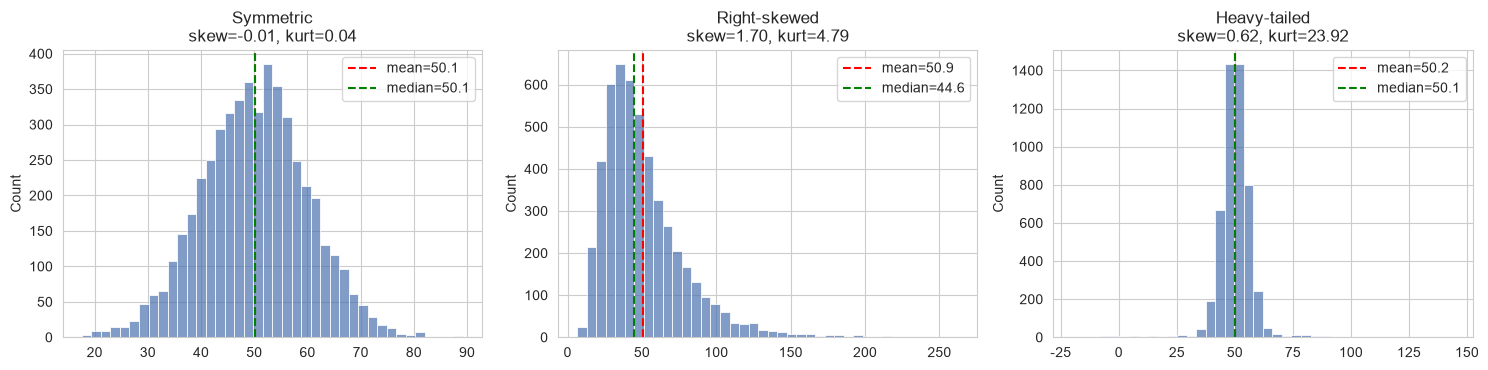

세 분포의 평균은 거의 같지만 모양은 전혀 다릅니다.


In [20]:
# [C8] 예제 2.2: 같은 평균인데 다른 모양 — 인공 데이터 세 개
np.random.seed(42)
N = 5000
sym  = np.random.normal(loc=50, scale=10, size=N)              # 좌우 대칭
right = np.random.lognormal(mean=np.log(45), sigma=0.5, size=N) # 우편향
heavy = np.concatenate([
    np.random.normal(loc=50, scale=5,  size=int(N*0.95)),
    np.random.normal(loc=50, scale=30, size=int(N*0.05)),       # 5% 극단값
])

fig, axes = plt.subplots(1, 3, figsize=(15, 3.8))
for ax, data, name in zip(axes,
                          [sym, right, heavy],
                          ["Symmetric", "Right-skewed", "Heavy-tailed"]):
    sns.histplot(data, bins=40, ax=ax, color="#4C72B0", alpha=0.7)
    ax.axvline(np.mean(data), color="red",   linestyle="--",
               label=f"mean={np.mean(data):.1f}")
    ax.axvline(np.median(data), color="green", linestyle="--",
               label=f"median={np.median(data):.1f}")
    ax.set_title(f"{name}\nskew={stats.skew(data):.2f}, kurt={stats.kurtosis(data):.2f}")
    ax.legend()
plt.tight_layout(); plt.show()

print("세 분포의 평균은 거의 같지만 모양은 전혀 다릅니다.")

> **읽는 법:** 세 분포의 **평균은 모두 50 근처**입니다. 하지만 모양은 전혀 다릅니다. 첫 번째는 대칭이라 평균과 중앙값이 거의 겹치고, 두 번째는 평균이 오른쪽으로 끌려갑니다. 세 번째는 좌우 대칭처럼 보여도 왜도가 양수일 수 있는 *두꺼운 꼬리*가 보입니다. **모양을 보지 않은 평균은 위험합니다.**

## 평균의 거짓말 — 다봉 분포

분포가 **봉우리가 두 개 이상**(다봉, multimodal)이면 평균은 _어디에도 존재하지 않는_ 값이 되기도 합니다. 펭귄의 체중 데이터를 봅시다 — 서로 다른 종(species)이 섞여 있거든요.

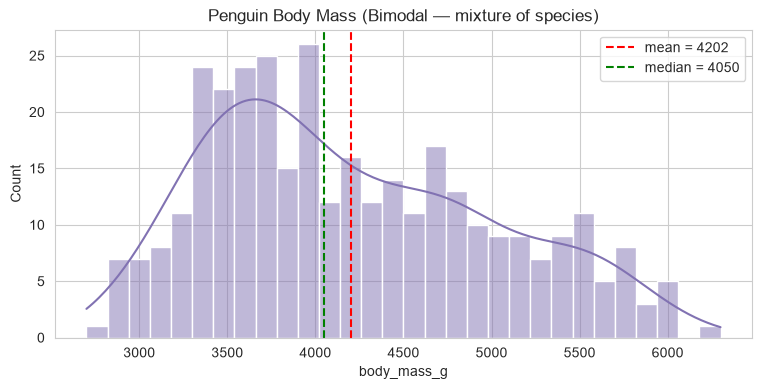

왜도: 0.47
첨도: -0.73  (음수 → 납작/다봉 신호)
→ 왜도가 0에 가깝다고 해서 정규분포라는 뜻은 아닙니다!


In [21]:
# [C9] 예제 2.3: 다봉 분포 — '평균'이 어디에도 없는 값일 때
bm = penguins["body_mass_g"].dropna()
fig, ax = plt.subplots(figsize=(9, 4))
sns.histplot(bm, bins=30, kde=True, ax=ax, color="#8172B2")
ax.axvline(bm.mean(),   color="red",   linestyle="--", label=f"mean = {bm.mean():.0f}")
ax.axvline(bm.median(), color="green", linestyle="--", label=f"median = {bm.median():.0f}")
ax.set_title("Penguin Body Mass (Bimodal — mixture of species)")
ax.set_xlabel("body_mass_g")
ax.legend(); plt.show()

print(f"왜도: {stats.skew(bm):.2f}")
print(f"첨도: {stats.kurtosis(bm):.2f}  (음수 → 납작/다봉 신호)")
print("→ 왜도가 0에 가깝다고 해서 정규분포라는 뜻은 아닙니다!")

> **읽는 법:** 봉우리가 둘로 보이나요? 펭귄 체중의 평균은 약 4,200g이지만 _정작 4,200g인 펭귄은 드뭅니다_. 몸집이 큰 Gentoo 종(약 5,000g)과 작은 Adelie·Chinstrap 종(약 3,700g)이 **섞여 있기** 때문입니다. 이런 다봉 분포에서 평균을 "대표값"으로 보고하면 **현실을 가립니다**. 종(집단)을 분리해 따로 분석해야 합니다 — Part 5에서 이걸 검정으로 확인합니다.

## ⚠️ 오늘의 흔한 오해 모음

> ❗ **"왜도 0 = 정규분포"는 거짓입니다.**
> 왜도는 *대칭성*만 봅니다. 위 만족도처럼 대칭인 다봉 분포는 왜도가 0에 가깝습니다. **모양을 그림으로 보는 단계를 건너뛰면 안 됩니다.**

> ❗ **첨도가 높다 = 분산이 크다 (X)**
> 첨도는 *꼬리의 두께*입니다. 분산이 같아도 첨도는 다를 수 있습니다.

## 📊 데이터로 확인해 봅시다

- **로그 변환의 신호:** 강한 양의 왜도(매출·소득 등)는 _로그 변환_($\log(x+1)$)으로 대칭에 가깝게 만들 수 있습니다 — 회귀·정규성 기반 검정의 가정을 만족시키기 위한 첫 시도.
- **이상치·체제 변화 의심:** 매우 높은 첨도는 _드물지만 극단적인_ 사건이 섞여 있다는 신호 — 그 사건을 따로 분석해야 할 수 있습니다.
- **모델 선택 신호:** 다봉이면 *두 집단을 분리*하거나 _혼합 모델(Mixture Model)_ 을 고려합니다 — 평균 하나로 합치지 않습니다.

> 📌 **다른 산업에서는?** 마케팅은 캠페인 반응 시간이 강한 우편향(대부분 빠르고 일부 매우 느림)인 경우가 많아 *중앙값*으로 보고합니다. 금융은 수익률 분포의 첨도를 항상 점검해 _블랙 스완(Black Swan)_ 위험을 측정합니다. 헬스케어는 환자군이 둘로 나뉘는 다봉 분포가 흔해 *서브그룹 분석*이 기본입니다.

## ⌨️ 백문이 불여일타! (2)

```
[문제]
1) titanic["fare"]의 왜도·첨도를 출력하고, 양의 왜도가 큰지 확인해보세요.
2) np.log1p(titanic["fare"])(로그 변환)의 왜도가 얼마나 줄어드는지 비교해보세요.
3) 어떤 변수의 왜도가 거의 0인데 첨도가 매우 크다면 분포 그림이 어떻게 생겼을지,
   추정과 근거를 주석으로 정리해보세요.
```

In [22]:
# [C10] ⌨️ 백문이 불여일타! (2) — fare의 왜도·첨도와 로그 변환 효과
fare_skew = titanic['fare'].skew()
fare_kurt = titanic['fare'].kurt()

print("왜도:", fare_skew)
print("첨도:", fare_kurt)

왜도: 4.787316519674893
첨도: 33.39814088089868


In [23]:
fare_log = np.log1p(titanic['fare'])
fare_log_skew = fare_log.skew()

print("로그 변환 후 왜도:", fare_log_skew)

로그 변환 후 왜도: 0.3949280095189306


In [24]:
# [문제3] 왜도 ≈ 0, 첨도 매우 큼 → 분포 모양 추정
#
# 왜도가 0에 가깝다는 것은 분포가 좌우 대칭이라는 뜻이다.
# 즉 오른쪽으로도 왼쪽으로도 치우치지 않는다.
#
# 동시에 첨도가 매우 크다는 것(leptokurtic)은
# 분포 중심이 뾰족하게 솟아있고, 양쪽 꼬리가 모두 두껍다는 뜻이다.
#
# 따라서 이런 변수는:
# - 대부분의 값이 평균 근처에 아주 촘촘하게 몰려있고
# - 좌우 양쪽으로 드물지만 극단적으로 큰/작은 값(outlier)이 대칭적으로 존재한다
#
# 예시 형태: 정규분포보다 훨씬 뾰족한 중심 + 양쪽으로 두꺼운 꼬리
# (금융 자산의 일일 수익률 분포가 대표적인 예 — 평소엔 변동 작지만
#  가끔 위아래로 급등락하는 이벤트가 대칭적으로 발생)

<details>
<summary>(클릭) 💡 힌트</summary>

- 왜도·첨도는 `stats.skew()`·`stats.kurtosis()`로 계산합니다 — [C7]에서 본 그 함수들입니다. `fare`에는 결측이 있으니 `dropna()`를 먼저 적용해보세요.
- 로그 변환은 `np.log1p()` 한 줄이면 됩니다 — 변환 전후의 왜도를 나란히 출력해 비교해보세요.
- 3번은 왜도와 첨도가 각각 분포의 어떤 측면을 담당하는지 떠올려보세요 — 대칭이면서도 꼬리가 두꺼운 분포가 있을 수 있습니다.

</details>

## 🚦 짚고 넘어가기

1. 왜도와 첨도는 각각 분포의 어떤 측면을 측정하나요?
2. "평균은 같지만 분포가 다를 수 있다"는 말을 직접 본 셀의 그림으로 설명할 수 있나요?
3. 다봉 분포에 평균을 대표값으로 보고하면 안 되는 이유는?

> 💡 **다음 Part 예고:** 지금까지는 *우리 데이터*의 모양을 묘사했습니다. 이제 한 단계 위로 올라가, "이런 모양은 어떤 *이론적 분포*와 닮았는가"를 묻습니다. 실무 변수는 거대한 분포 카탈로그 중 몇 가지 모양에 자주 닮습니다. **그 카탈로그를 외우는 것이 다음 Part입니다.**

# Part 3. 확률분포 4종 — 정규·이항·포아송·지수

같은 의류 쇼핑몰에서 본 변수들이라도 *생성되는 방식*이 다르면 분포의 모양도 달라집니다.

- 키·몸무게처럼 _많은 작은 요인의 합_ — **정규분포**
- 쿠폰을 받은 1,000명 중 사용한 사람 수처럼 _Yes/No 시행의 횟수_ — **이항분포**
- 일별 매장 방문 수처럼 _드물게 일어나는 사건의 합_ — **포아송분포**
- 다음 주문까지 걸린 시간처럼 _대기 시간_ — **지수분포**

실무 데이터는 _몇 가지 모양_ 중 하나에 자주 닮습니다. 그 닮은꼴을 알면 적합한 검정·모델을 고를 수 있습니다.

> ❓ **이 파트에서 답할 질문:**우리 데이터의 모양이 어떤 _이론적 분포_ 와 닮았다면, 그 사실은 어떻게 알아채고 활용할 수 있을까?

## 💡 쉽게 말하면 —"어떻게 생성되었는가"가 모양을 결정한다

```text
정규(normal)      ~  많은 작은 요인의 합     (키, 평균 점수, 측정 오차)
이항(binomial)    ~  Yes/No를 n번 한 결과    (n명 중 클릭한 사람 수)
포아송(Poisson)   ~  단위 시간 동안의 발생수  (시간당 통화 수, 일일 방문수)
지수(exponential) ~  사건 사이의 대기 시간   (다음 주문까지의 일수)
```

> 💡 **개념 연결:** 이항분포에서 시행 횟수가 매우 크고 확률이 매우 작으면 → 포아송으로 근사됩니다. 포아송에서 사건의 *간격*은 → 지수분포가 됩니다. 그리고 _큰 표본의 평균_ 분포는 → 항상 정규에 가까워집니다(**중심극한정리, CLT**). 네 분포는 따로가 아니라 _한 가족_ 입니다.

## 정규분포 (Normal Distribution)

$$X \sim N(\mu, \sigma^2)$$

확률밀도함수(PDF):

$$f(x) = \frac{1}{\sigma\sqrt{2\pi}} \exp\!\left( -\frac{(x-\mu)^2}{2\sigma^2} \right)$$

| 기호                      | 의미                                                    |
| ------------------------- | ------------------------------------------------------- |
| $X \sim N(\mu, \sigma^2)$ | "$X$는 평균 $\mu$, 분산 $\sigma^2$인 정규분포를 따른다" |
| $f(x)$                    | $x$에서의 확률밀도 (높을수록 그 근처의 값이 자주 나옴)  |
| $\exp(\cdot)$             | 자연 지수함수 $e^{(\cdot)}$                             |

- **모양:** 좌우 대칭, 종 모양(Bell Curve), 평균 근처에 가장 많고 양 꼬리로 갈수록 빠르게 줄어듭니다.
- **68-95-99.7 규칙:** 평균 ± 1$\sigma$ 안에 약 68%, ± 2$\sigma$ 안에 약 95%, ± 3$\sigma$ 안에 약 99.7%가 들어옵니다.

> 📌 **실무 발현:** 평균 구매 금액, 시험 점수, 측정 오차, 키·몸무게처럼 _많은 독립 요인의 합_ 으로 만들어지는 변수.

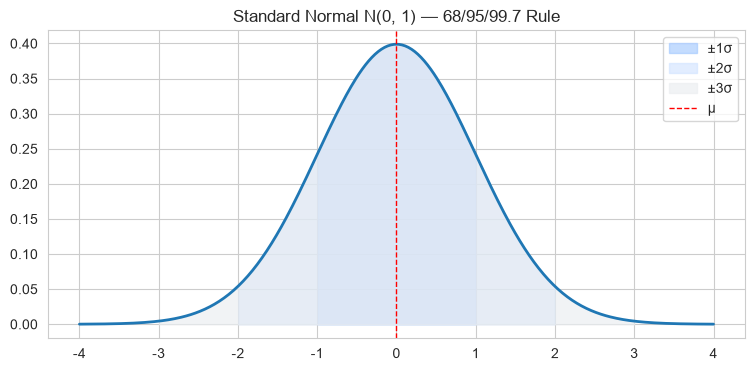

±1σ 안 확률: 0.683
±2σ 안 확률: 0.954
±3σ 안 확률: 0.997


In [25]:
# [C11] 예제 3.1: 정규분포 PDF — 68-95-99.7 규칙
mu, sigma = 0, 1
x = np.linspace(-4, 4, 400)
pdf = stats.norm.pdf(x, loc=mu, scale=sigma)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(x, pdf, lw=2)
for k, color in zip([1, 2, 3], ["#9ec5fe", "#cfe2ff", "#e9ecef"]):
    ax.fill_between(x, pdf, where=(x >= -k) & (x <= k), color=color, alpha=0.6,
                    label=f"±{k}σ")
ax.axvline(mu, color="red", linestyle="--", lw=1, label="μ")
ax.set_title("Standard Normal N(0, 1) — 68/95/99.7 Rule")
ax.legend(); plt.show()

print("±1σ 안 확률:", round(stats.norm.cdf(1) - stats.norm.cdf(-1), 3))
print("±2σ 안 확률:", round(stats.norm.cdf(2) - stats.norm.cdf(-2), 3))
print("±3σ 안 확률:", round(stats.norm.cdf(3) - stats.norm.cdf(-3), 3))

> **읽는 법:** 표준정규분포($\mu=0, \sigma=1$)의 종 모양입니다. 평균 근처에 가장 자주, 멀어질수록 _지수적으로_ 빠르게 줄어듭니다. ±2$\sigma$ 안에 95%가 들어온다는 것이 이후 배울 95% 신뢰구간과 같은 뿌리입니다.

## 이항분포 (Binomial Distribution)

$$X \sim \text{Binomial}(n, p) \qquad P(X = k) = \binom{n}{k} p^k (1-p)^{n-k}$$

| 기호           | 의미                                      |
| -------------- | ----------------------------------------- |
| $n$            | 시행 횟수                                 |
| $p$            | 한 번의 시행에서 성공할 확률              |
| $k$            | 성공 횟수 (관측값)                        |
| $\binom{n}{k}$ | $n$개 중 $k$개를 고르는 가짓수 (이항계수) |

- **평균** $= np$, **분산** $= np(1-p)$
- $n$이 크고 $p$가 0.5에 가까우면 → 정규로 근사 가능.

> 📌 **실무 발현:** 1000명에게 쿠폰 발송 → 사용한 사람 수. A/B 테스트에서 _전환된 인원 수_.

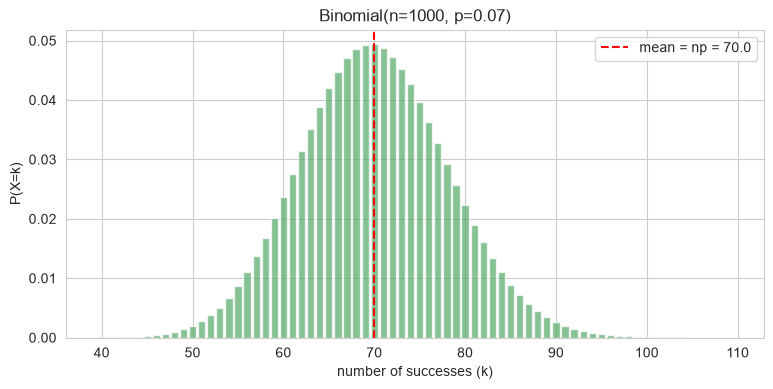

이론 평균(np): 70.0, 표본평균: 69.6
이론 표준편차: 8.07, 표본표준편차: 8.07


In [26]:
# [C12] 예제 3.2: 이항분포 — n=1000, p=0.07 (쿠폰 사용 횟수)
n_trials, p = 1000, 0.07
x = np.arange(40, 110)
pmf = stats.binom.pmf(x, n_trials, p)

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(x, pmf, color="#55A868", alpha=0.7)
ax.axvline(n_trials * p, color="red", linestyle="--", label=f"mean = np = {n_trials*p}")
ax.set_title(f"Binomial(n={n_trials}, p={p})")
ax.set_xlabel("number of successes (k)"); ax.set_ylabel("P(X=k)")
ax.legend(); plt.show()

# 같은 분포에서 표본을 뽑아 이론과 비교 (시뮬레이션, seed 고정)
sample = stats.binom.rvs(n_trials, p, size=365, random_state=42)
print(f"이론 평균(np): {n_trials*p:.1f}, 표본평균: {sample.mean():.1f}")
print(f"이론 표준편차: {np.sqrt(n_trials*p*(1-p)):.2f}, 표본표준편차: {sample.std():.2f}")

> **읽는 법:** 이론 평균($np = 70$)과 시뮬레이션 표본평균이 매우 가깝습니다. 이항분포는 "_시도하고 결과를 세는_"(쿠폰 사용·클릭·전환 등) 모든 상황의 기본 모형입니다. 이후 배울 A/B 테스트 분석에서 그대로 다시 등장합니다.

## 포아송분포 (Poisson Distribution)

$$X \sim \text{Poisson}(\lambda) \qquad P(X = k) = \frac{\lambda^k e^{-\lambda}}{k!}$$

| 기호             | 의미                                                   |
| ---------------- | ------------------------------------------------------ |
| $\lambda$ (람다) | 단위 시간(또는 단위 공간)당 평균 발생 횟수             |
| $k$              | 실제 발생 횟수                                         |
| $k!$             | $k$ 팩토리얼 ($k \times (k-1) \times \cdots \times 1$) |

- **평균 = 분산 = $\lambda$** (포아송의 결정적 특징)
- 사건이 _독립적이고 드물게_ 일어날 때.

> 📌 **실무 발현:** 시간당 콜센터 통화 수, 일일 매장 방문 수, 시간당 웹사이트 에러 수.

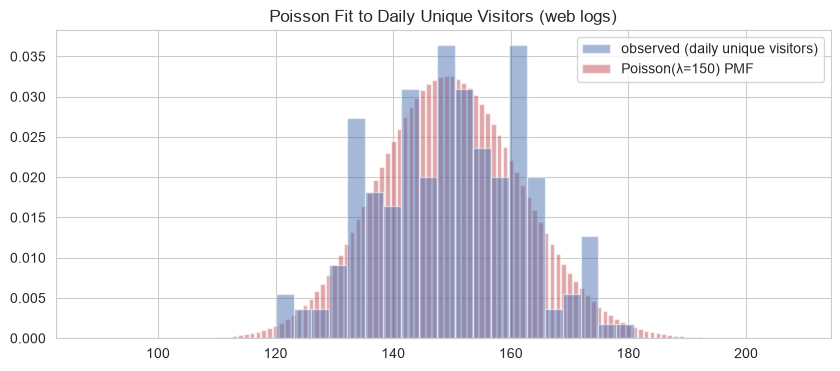

포아송 가정 점검: 평균 ≈ 분산?
표본평균: 149.6
표본분산: 149.3
분산/평균 비 = 1.00  (1에 가까울수록 포아송 닮음)


In [27]:
# [C13] 예제 3.3: 포아송 — 웹로그 '일별 고유 방문자 수' 실데이터와 비교
lam = visitors.mean()
span = max(60, int(3 * np.sqrt(lam)))
x = np.arange(max(0, int(lam - span)), int(lam + span))
pmf = stats.poisson.pmf(x, lam)

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(x, pmf, color="#C44E52", alpha=0.5, label=f"Poisson(λ={lam:.0f}) PMF")
ax.hist(visitors, bins=20, density=True, alpha=0.5,
        color="#4C72B0", label="observed (daily unique visitors)")
ax.set_title("Poisson Fit to Daily Unique Visitors (web logs)")
ax.legend(); plt.show()

print("포아송 가정 점검: 평균 ≈ 분산?")
print(f"표본평균: {visitors.mean():.1f}")
print(f"표본분산: {visitors.var():.1f}")
print(f"분산/평균 비 = {visitors.var()/visitors.mean():.2f}  (1에 가까울수록 포아송 닮음)")

> **읽는 법:** 이론(빨강)과 관측(파랑)이 잘 겹칩니다. 그리고 **포아송의 특징인 "평균 = 분산"** 이 *실제 웹 로그*에서도 거의 성립합니다(분산/평균 비가 1 근처). 만약 분산이 평균보다 _훨씬 크다면_ "_과대산포(Overdispersion)_" 라고 부르며, 음이항(Negative Binomial) 같은 다른 분포로 갈아탑니다. 실데이터라 완벽하진 않아도 포아송 닮은꼴이 분명합니다.

## 지수분포 (Exponential Distribution)

$$X \sim \text{Exp}(\lambda) \qquad f(x) = \lambda e^{-\lambda x},\ \ x \ge 0$$

| 기호        | 의미                                     |
| ----------- | ---------------------------------------- |
| $\lambda$   | 발생률(Rate). 단위 시간당 평균 발생 횟수 |
| $1/\lambda$ | 기대 대기 시간 (평균)                    |

- **무기억성(Memoryless):** 이미 5분을 기다렸든 1시간을 기다렸든, _남은 대기 시간의 분포는 같다_. 직관에 반하지만 수학적으로 그렇습니다.
- 포아송 사건의 _간격_ 이 곧 지수분포입니다.

> 📌 **실무 발현:** 재구매까지 시간, 부품 수명, 콜센터 다음 전화까지의 간격.

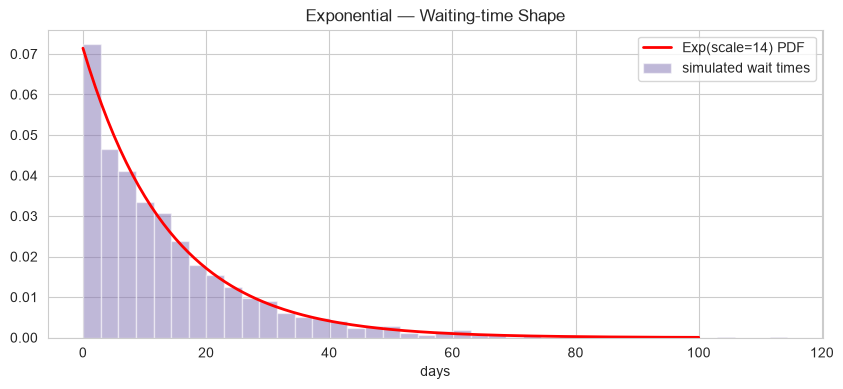

지수분포의 특성: 평균 ≈ 표준편차
표본평균: 14.05
표본표준편차: 14.15


In [28]:
# [C14] 예제 3.4: 지수분포 — '재구매까지 일수' (대기시간, 시뮬레이션·seed 고정)
# 지수분포는 사건 사이 '대기시간'의 모형 — 깔끔한 형태를 보이려 통제 생성합니다.
wait = stats.expon.rvs(scale=14, size=2000, random_state=42)   # 평균 14일
x = np.linspace(0, 100, 200)
pdf = stats.expon.pdf(x, scale=14)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(x, pdf, color="red", lw=2, label="Exp(scale=14) PDF")
ax.hist(wait, bins=40, density=True, alpha=0.5,
        color="#8172B2", label="simulated wait times")
ax.set_title("Exponential — Waiting-time Shape")
ax.set_xlabel("days"); ax.legend(); plt.show()

print("지수분포의 특성: 평균 ≈ 표준편차")
print(f"표본평균: {wait.mean():.2f}")
print(f"표본표준편차: {wait.std():.2f}")

> **읽는 법:** 0에서 가장 높고 _오른쪽으로 빠르게 감소_ 하는 모양. 평균이 14일이라도 *7일 안에 재구매*할 확률이 *약 40%*입니다($1-e^{-0.5}\approx0.39$ — 대기 시간 분포의 특징). 가입 직후의 고객 행동을 모델링할 때 자주 등장합니다.

## 📊 데이터로 확인해 봅시다 — 분포 닮음꼴 카탈로그

| 변수 성격         | 닮은꼴 분포 | 후속 분석에 자주 쓰이는 도구             |
| ----------------- | ----------- | ---------------------------------------- |
| 연속·대칭·종 모양 | 정규        | t-test, ANOVA, OLS 회귀                  |
| 정수·시행 횟수    | 이항        | 카이제곱·A/B 비율 검정                   |
| 정수·발생 횟수    | 포아송      | 포아송 회귀 (심화)                       |
| 양수·대기 시간    | 지수        | 생존 분석(survival analysis, 본 모듈 외) |
| 비율(0~1)         | 베타        | 베이지안 A/B (**다음 Part!**)            |
| 다봉              | 혼합        | 서브그룹 분리·클러스터링                 |

> 📌 **다른 산업에서는?** 제조의 부품 수명 → _지수_(또는 와이블), 금융 거래 빈도 → _포아송_, 마케팅 클릭률 → _이항/베타_, 헬스케어 환자 도착 간격 → _지수_. 한 분포의 모양을 알면 *여러 산업의 비슷한 문제*에 같은 도구를 씁니다.

## ⌨️ 백문이 불여일타! (3)

```
[문제]
1) scipy.stats.norm.rvs(loc=170, scale=7, size=500)로 가상 키 데이터를 만들고 히스토그램을 그려보세요.
2) scipy.stats.poisson.rvs(mu=5, size=500)로 "시간당 통화 수"를 만들고, 평균과 분산이 거의 같은지 확인해보세요.
3) "쿠폰 발송 1000명 중 사용한 사람 수"는 어떤 분포에 닮았을지, 같은 데이터를 비율(7%) 단위로
   보면 어떤 분포가 자연스러울지 판단과 근거를 주석으로 정리해보세요.
```

In [30]:
plt.rcParams['font.family'] = 'Malgun Gothic'

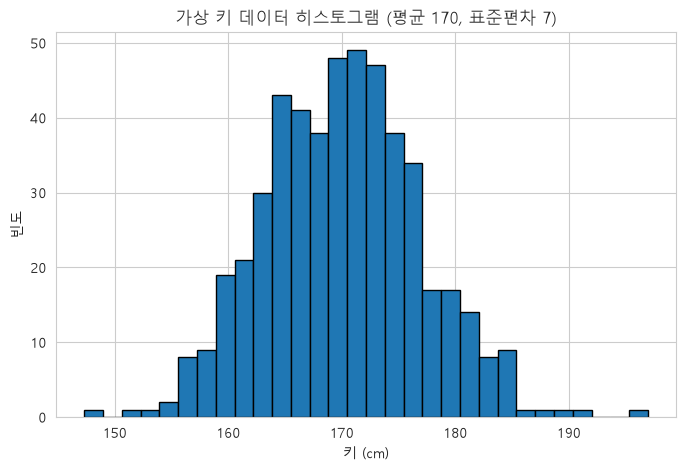

In [31]:
# [C15] ⌨️ 백문이 불여일타! (3) — 정규·포아송 난수 생성과 평균·분산 비교
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

np.random.seed(42)  # 재현 가능하게

heights = stats.norm.rvs(loc=170, scale=7, size=500)

plt.figure(figsize=(8, 5))
plt.hist(heights, bins=30, edgecolor='black')
plt.title('가상 키 데이터 히스토그램 (평균 170, 표준편차 7)')
plt.xlabel('키 (cm)')
plt.ylabel('빈도')
plt.show()

평균: 4.992
분산: 5.115936


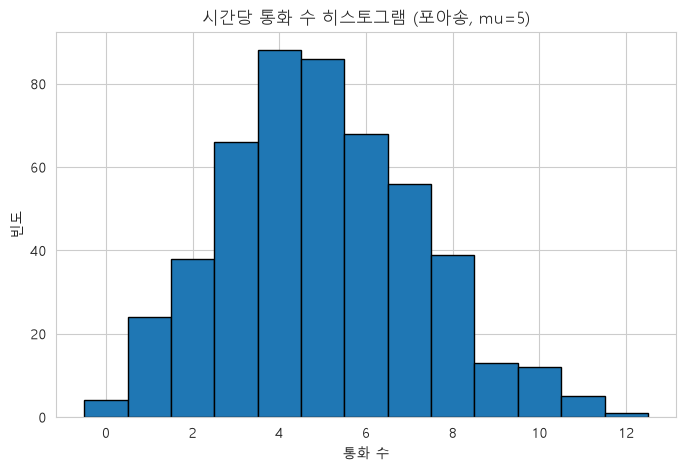

In [32]:
calls = stats.poisson.rvs(mu=5, size=500)

calls_mean = calls.mean()
calls_var = calls.var()

print("평균:", calls_mean)
print("분산:", calls_var)

plt.figure(figsize=(8, 5))
plt.hist(calls, bins=range(0, calls.max()+2), edgecolor='black', align='left')
plt.title('시간당 통화 수 히스토그램 (포아송, mu=5)')
plt.xlabel('통화 수')
plt.ylabel('빈도')
plt.show()

In [ ]:
# [문제3] 쿠폰 사용자 수는 어떤 분포?
#
# 1000명 각각이 "쿠폰을 쓴다/안 쓴다"의 독립적인 이진 결과를 가지며,
# 사용 확률이 7%로 고정되어 있다.
# → 고정된 시행 횟수(n=1000) + 이진 결과 + 동일하고 독립적인 확률
#   = 이항분포(Binomial(n=1000, p=0.07))의 전형적인 조건이다.
#
# 참고: n이 크고 p가 작을 때는 이항분포가 포아송분포(λ=n*p=70)로
# 근사될 수 있지만, 원래 발생 구조 자체는 이항분포가 정확한 모델이다.

# 비율(사용자수 / 1000)로 보면?
#
# n=1000이 충분히 크고 np=70, n(1-p)=930 모두 크므로
# 이항분포는 정규분포로 근사할 수 있다 (중심극한정리).
#
# 평균 = p = 0.07
# 표준오차 = sqrt(p*(1-p)/n) ≈ sqrt(0.07*0.93/1000) ≈ 0.0081
#
# 따라서 "쿠폰 사용 비율"은 평균 0.07, 표준편차 약 0.008인
# 정규분포에 가깝게 나타날 것으로 예상할 수 있다.

<details>
<summary>(클릭) 💡 힌트</summary>

- 난수 재현을 위해 `random_state=0`을 함께 넘기면 결과가 고정됩니다. 히스토그램은 `sns.histplot()`이면 충분합니다 — [C11]~[C14]에서 만난 분포들입니다.
- 포아송 표본의 평균과 분산은 `mean()`·`var()`로 확인해보세요 — 두 값이 비슷한지가 관전 포인트입니다.
- 3번은 "횟수를 세는" 상황과 "0~1 사이 비율"에 각각 어울리는 분포를 이번 Part의 카탈로그에서 골라보세요.

</details>

## 🚦 짚고 넘어가기

1. 정규·이항·포아송·지수 각각이 _닮은_ 실무 변수 한 개씩을 댈 수 있나요?
2. 포아송의 특징적 가정 _"평균 = 분산"_ 의 의미는?
3. 지수분포의 무기억성은 직관에 어긋나는데, 이걸 *비즈니스적*으로는 어떻게 해석할까요? (힌트: 이미 5분 기다린 손님과 방금 온 손님)

> 💡 **다음 Part 예고:** 위 네 분포는 모두 _값_ 의 분포였습니다. 하지만 우리가 자주 만나는 _비율(전환율·클릭률)_ 은 이 카탈로그에 잘 안 맞습니다. 0과 1 사이에 갇혀 있고, _표본이 적을 때 평균이 위험_ 합니다. 이를 위한 도구가 다음 Part의 **베타분포** 입니다.

# Part 4. 베타분포 — 비율의 불확실성을 표현하다

전환율 _5/20 = 25%_ 와 _5,000/20,000 = 25%_ 는 같은 값이지만, *얼마나 믿을 수 있나*는 완전히 다릅니다. 표본이 적을수록 같은 비율도 _덜 확실_ 합니다.

문제는 **확률 분포 가족 중에 0~1 사이의 비율을 자연스럽게 다루는 것** 이 위에서 본 네 가지에 없다는 점입니다. 그래서 비율 데이터의 **불확실성을 표현하는 전용 분포**가 등장합니다 — 베타분포(Beta Distribution).

> ❓ **이 파트에서 답할 질문:\***적은 표본의 비율\* 을 점추정(25%) 하나로 보고하면 안 되는 이유는? 불확실성을 어떻게 함께 표현할까?

## 💡 쉽게 말하면 —"성공 α번, 실패 β번을 봤을 때 진짜 비율은 어디?"

베타분포의 모수는 두 개입니다 — $\alpha$(알파)와 $\beta$(베타). 직관적 해석은:

```text
α  ~  "지금까지 본 성공 횟수 + 1"
β  ~  "지금까지 본 실패 횟수 + 1"
```

데이터가 쌓일수록 분포는 _좁고 뾰족_ 해지고(불확실성↓), 데이터가 적을수록 _넓고 평평_ 합니다(불확실성↑).

| 상황                     | $(\alpha, \beta)$ | 분포 모양                 | 평균           |
| ------------------------ | ----------------- | ------------------------- | -------------- |
| 아무 정보 없음           | $(1, 1)$          | 균등 (uniform)            | 0.5            |
| 성공 1·실패 1            | $(2, 2)$          | 0.5 근처에 약간 뾰족      | 0.5            |
| 성공 5·실패 15 (n=20)    | $(6, 16)$         | 0.25 근처 봉우리, 좀 넓음 | $\approx 0.27$ |
| 성공 50·실패 150 (n=200) | $(51, 151)$       | 0.25 근처 매우 뾰족       | $\approx 0.25$ |

> 💡 **개념 연결:** 위 표는 **베이지안 사후 업데이트(Posterior Update)** 의 그림자입니다. 사전(Prior) $\text{Beta}(1, 1)$ 에 데이터 $(s, f)$를 더하면 사후(Posterior) $\text{Beta}(1+s, 1+f)$. 같은 데이터를 *빈도주의 신뢰구간*과 _베이지안 신용구간_ 두 방식 모두로 표현할 수 있습니다 — **A/B 베이지안 편**에서 이 도구가 본격 등장합니다.

## 베타분포, 수식으로

$$X\sim \text{Beta}(\alpha, \beta) \qquad f(x) = \frac{x^{\alpha-1}(1-x)^{\beta-1}}{B(\alpha, \beta)},\ \ 0 \le x \le 1$$

| 기호               | 의미                                           |
| ------------------ | ---------------------------------------------- |
| $\alpha, \beta$    | 형태 모수(Shape Parameter). 모두 양수.         |
| $B(\alpha, \beta)$ | 베타 함수 — 적분을 1로 만들기 위한 정규화 상수 |

평균과 분산:

$$\text{E}[X] = \frac{\alpha}{\alpha + \beta} \qquad \text{Var}(X) = \frac{\alpha\beta}{(\alpha + \beta)^2(\alpha + \beta + 1)}$$

분산은 $\alpha + \beta$가 클수록(=관측 수가 많을수록) **작아집니다**. 데이터가 많아지면 불확실성이 줄어든다는 직관과 일치합니다.

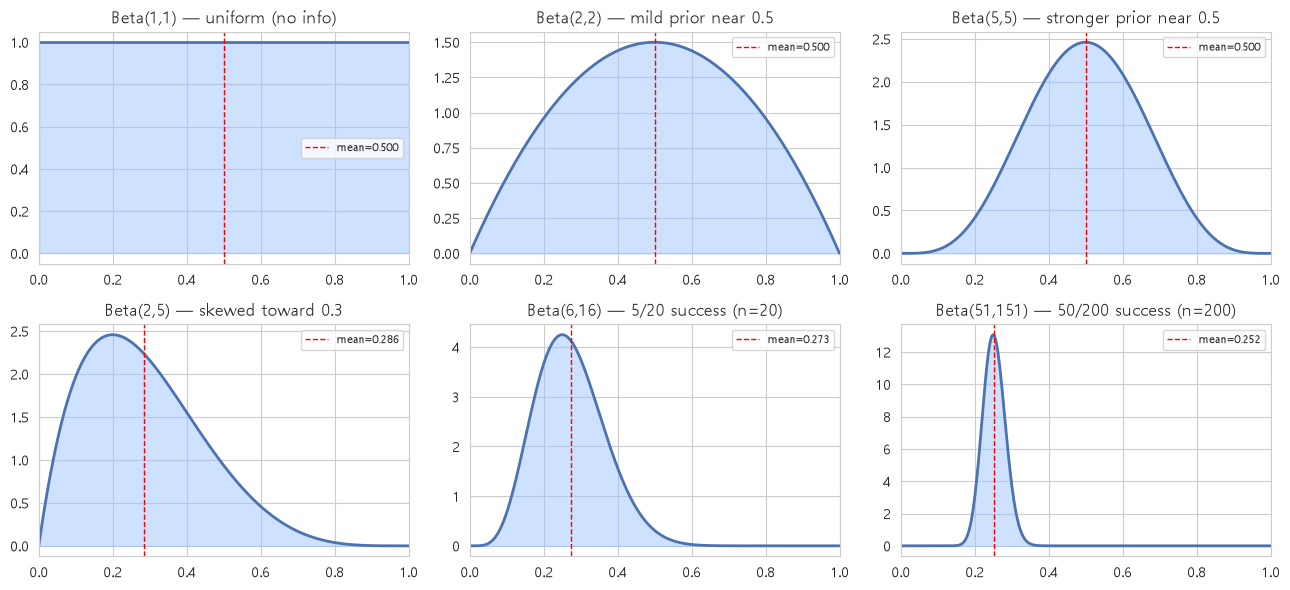

In [33]:
# [C16] 예제 4.1: α, β를 바꾸면 모양이 어떻게 변하나
fig, axes = plt.subplots(2, 3, figsize=(13, 6))
params = [(1, 1), (2, 2), (5, 5),
          (2, 5), (6, 16), (51, 151)]
titles = ["Beta(1,1) — uniform (no info)",
          "Beta(2,2) — mild prior near 0.5",
          "Beta(5,5) — stronger prior near 0.5",
          "Beta(2,5) — skewed toward 0.3",
          "Beta(6,16) — 5/20 success (n=20)",
          "Beta(51,151) — 50/200 success (n=200)"]

x = np.linspace(0, 1, 400)
for ax, (a, b), title in zip(axes.flatten(), params, titles):
    ax.plot(x, stats.beta.pdf(x, a, b), color="#4C72B0", lw=2)
    ax.fill_between(x, stats.beta.pdf(x, a, b), color="#9ec5fe", alpha=0.5)
    mean = a / (a + b)
    ax.axvline(mean, color="red", linestyle="--", lw=1, label=f"mean={mean:.3f}")
    ax.set_title(title); ax.set_xlim(0, 1); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

> **읽는 법:** 마지막 두 그림이 핵심입니다. 둘 다 평균은 0.25 근처지만, 데이터가 _10배 많은_ 마지막 그림은 분포가 _훨씬 좁고 뾰족_ 합니다. **같은 점추정도 표본이 크면 더 좁은 베타분포로 표현됩니다** — 이것이 곧 "표본이 클수록 비율의 추정이 더 확실하다"는 직관의 수학 표현입니다.

## 적은 표본 vs 큰 표본 — 같은 25%, 다른 불확실성

5/20 (n=20)         95% credible interval = [0.113, 0.472]   width = 0.359
50/200 (n=200)      95% credible interval = [0.195, 0.314]   width = 0.119
500/2000 (n=2000)   95% credible interval = [0.232, 0.269]   width = 0.038


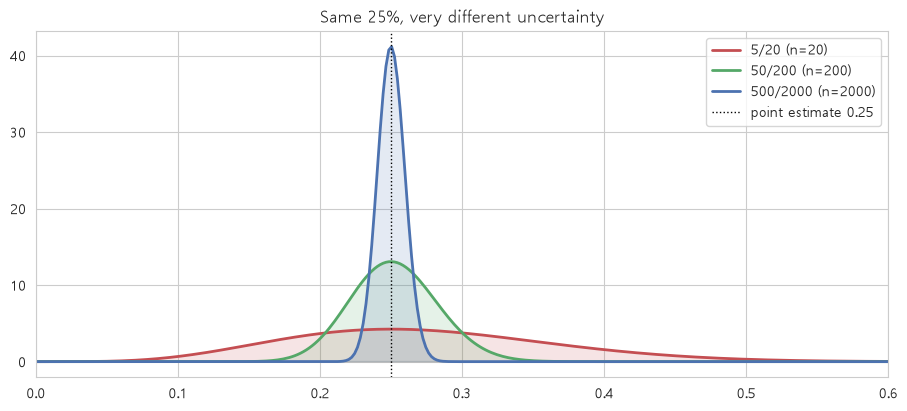

In [34]:
# [C17] 예제 4.2: 5/20 vs 50/200 vs 500/2000 — 같은 25%
data = [(5, 15), (50, 150), (500, 1500)]
labels = ["5/20 (n=20)", "50/200 (n=200)", "500/2000 (n=2000)"]
colors = ["#C44E52", "#55A868", "#4C72B0"]

x = np.linspace(0, 1, 500)
fig, ax = plt.subplots(figsize=(11, 4.5))
for (s, f), lab, c in zip(data, labels, colors):
    a, b = s + 1, f + 1
    pdf = stats.beta.pdf(x, a, b)
    ax.plot(x, pdf, color=c, lw=2, label=lab)
    ax.fill_between(x, pdf, color=c, alpha=0.15)
    # 95% 신용구간(credible interval) 표시
    lo, hi = stats.beta.ppf([0.025, 0.975], a, b)
    print(f"{lab:18s}  95% credible interval = [{lo:.3f}, {hi:.3f}]   width = {hi-lo:.3f}")

ax.axvline(0.25, color="black", linestyle=":", lw=1, label="point estimate 0.25")
ax.set_title("Same 25%, very different uncertainty")
ax.set_xlim(0, 0.6); ax.legend(); plt.show()

> **읽는 법:** 셋 다 점추정은 25%지만, 95% 신용구간(Credible Interval)의 폭이 _4배~16배 차이_ 가 납니다. 점추정 하나만 보면 같아 보이지만, 베타분포로 표현하면 _얼마나 다른 확신_ 인지 한눈에 드러납니다. 이것이 베타분포가 비율 데이터에 어울리는 이유입니다.

> 💡 **결과 해석의 3종 세트(ASA 권고):** ① 점추정(0.25) ② 불확실성(95% 신용구간 [lo, hi]) ③ 효과 크기(여기서는 비율 자체) — _항상 셋을 함께_ 보고합니다. p-value 하나로 끝내지 않는 습관이 이 모듈 전체의 핵심 태도입니다.

## ⚠️ 오늘의 흔한 오해 모음

> ❗ **"베타분포 = 베이지안"이 아닙니다.**
> 베타분포는 그저 0~1 사이를 잘 표현하는 분포일 뿐입니다. 단, 그 형태가 *베이지안 업데이트*에 매우 잘 맞기 때문에 함께 자주 쓰입니다.

> ❗ **표본이 매우 적을 때(예: 0/5) 점추정 0%는 _0이라는 뜻이 아닙니다_.**
> 베타분포로 표현하면 "확률은 분명 낮지만 0이라고 단정할 수 없다"가 자연스럽게 드러납니다. _점추정의 단정 위험_ 을 줄여주는 도구입니다.

## 📊 데이터로 확인해 봅시다

- A/B 테스트에서 _대안의 전환율 분포를 비교_ (베이지안 A/B 비교)
- 콜드 스타트 상황(신규 캠페인·신상품)에서 _적은 표본의 비율을 정직하게 표현_
- 추천 시스템의 _신뢰도 가중_("좋아요 5/10"과 "좋아요 5,000/10,000"을 다르게 다루기)

> 📌 **다른 산업에서는?** 마케팅은 신규 광고 카피의 클릭률을 1주만 본 데이터로 비교할 때 베타사후로 정직하게 보고합니다. 헬스케어는 희귀 환자군의 반응률을 분포로 표현(점추정 단정의 위험). 제조는 신규 라인의 *초기 불량률*에 베타사전을 둬 *과거 라인 정보*를 부드럽게 가져옵니다.

## ⌨️ 백문이 불여일타! (4)

```
[문제]
1) Beta(2, 2)의 PDF를 그리고 평균을 출력해보세요. (평균 = α/(α+β))
2) 신규 캠페인이 10명 중 3명 전환(3/10)이라고 합시다. 사후 베타분포 Beta(4, 8)을 그리고
   95% 신용구간을 출력해보세요. (사전 = Beta(1,1) 균등 가정)
3) 두 캠페인 A(3/10)와 B(30/100)의 점추정이 같습니다(30%). 둘 중 "진짜 전환율 35% 이상일
   확률"이 더 높은 쪽을 코드로 확인하고, 그 이유를 주석으로 정리해보세요.
```

In [ ]:
# [C18] ⌨️ 백문이 불여일타! (4) — 베타분포 PDF·신용구간·전환율 확률 비교

# 여기에 코드를 작성하세요

<details>
<summary>(클릭) 💡 힌트</summary>

- PDF 곡선은 `np.linspace(0, 1, 300)` 위에서 `stats.beta.pdf(x, a, b)` 값을 그리면 됩니다 — [C16]에서 본 그 패턴입니다.
- 95% 신용구간은 `stats.beta.ppf([0.025, 0.975], a, b)`로, "35% 이상일 확률"은 `1 - stats.beta.cdf(0.35, a, b)`로 계산합니다.
- 사후 분포의 α·β는 "사전 + 관측"입니다 — 성공 횟수는 α에, 실패 횟수는 β에 더해보세요.

</details>

## 🚦 짚고 넘어가기

1. 베타분포가 0~1 사이를 다룬다는 사실 외에, 데이터 분석에 특히 유용한 _추가 강점_ 은 무엇인가요?
2. 같은 점추정(예: 25%)이라도 표본 크기에 따라 분포가 달라지는 이유를 설명할 수 있나요?
3. p-value 한 숫자가 _놓치는_ 정보를 베타분포가 어떻게 보충하나요?

> 💡 **다음 Part 예고:** 지금까지 분포 카탈로그를 만나봤습니다. 그런데 "_이 데이터가 정규다/이항이다_"라고 우리가 _어떻게_ 객관적으로 보일 수 있을까요? 시각적 진단(Q-Q plot)과 통계 검정(Shapiro-Wilk)으로 **분포 적합성**을 판정하는 도구가 다음 Part입니다.

# Part 5. 적합성 검증 — Q-Q plot · Shapiro-Wilk

지금까지 우리는 *분포의 모양*을 묘사하고, *이론적 분포 카탈로그*를 봤습니다. 마지막 단계는 **"내 데이터가 정말 그 분포에 가까운가"** 를 객관적으로 보이는 일입니다.

두 가지 도구를 씁니다.

1. **시각적 진단** — Q-Q plot (가장 강력하고 정직한 도구)
2. **수치적 검정** — Shapiro-Wilk (정규성 검정의 표준)

> ❓ **이 파트에서 답할 질문:**우리 데이터가 정규(또는 다른 이론 분포)에 _얼마나 가까운지_ 어떻게 판단할까?

## 💡 쉽게 말하면 — Q-Q plot은"두 분포의 분위수를 점 찍어 비교한다"

Q-Q는 _Quantile-Quantile_ 의 약자입니다.

```text
x축: 이론 분포(예: 정규)의 분위수(quantile)
y축: 우리 데이터의 분위수

점들이 대각선 위에 일직선으로 놓이면 → "이 데이터는 이론 분포에 매우 가깝다"
대각선에서 휘면 → "이 부분이 달라진다"  (꼬리/중앙/한쪽 어디서 휘는지로 진단)
```

> 💡 **분위수란?** 데이터를 정렬했을 때 *몇 % 위치의 값*입니다. 중앙값은 _50% 분위수_. 사분위는 _25%, 50%, 75%_ 분위수.

Q-Q plot은 **모든 분위수를 다 비교** 하므로, 평균·표준편차·왜도·첨도 같은 _요약 통계_ 가 놓치는 차이도 잡아냅니다.

In [ ]:
# [C19] 예제 5.1: Q-Q plot — 대칭(나이) vs 우편향(운임) vs 다봉(체중)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

stats.probplot(titanic["age"].dropna(), dist="norm", plot=axes[0])
axes[0].set_title("titanic.age — near normal?")

stats.probplot(titanic["fare"].dropna(), dist="norm", plot=axes[1])
axes[1].set_title("titanic.fare — right-skewed")

stats.probplot(penguins["body_mass_g"].dropna(), dist="norm", plot=axes[2])
axes[2].set_title("penguins.body_mass — bimodal")

plt.tight_layout(); plt.show()

> **읽는 법:** 왼쪽(나이) — 점들이 빨간 직선에 _대체로_ 붙어 있습니다(완벽하진 않지만 정규에 가깝다는 신호). 가운데(운임) — 오른쪽 끝(상위 분위수)에서 점들이 _위로_ 크게 벗어납니다. _우편향_(큰 꼬리)의 전형적 패턴입니다. 오른쪽(체중) — 점들이 _S자/계단식_ 으로 휩니다. *다봉*의 시각적 신호.
>
> **Q-Q plot은 분포에 대해 _어디서, 어떻게_ 차이가 나는지까지 알려줍니다.** 그래서 정규성 검정에서 Q-Q plot을 빼면 안 됩니다.

In [ ]:
# [C20] 예제 5.2: 다른 이론 분포에도 비교 가능 — 지수분포 적합성
# '대기시간' 형태를 보이려 통제 생성(seed 고정)
wait = stats.expon.rvs(scale=14, size=500, random_state=42)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
stats.probplot(wait, dist="expon", plot=axes[0])
axes[0].set_title("wait times vs Exponential (good fit)")
stats.probplot(wait, dist="norm", plot=axes[1])
axes[1].set_title("wait times vs Normal (mismatch)")
plt.tight_layout(); plt.show()

> **읽는 법:** 같은 _대기시간_ 데이터를 두 이론 분포(지수·정규)에 견줘봤습니다. 왼쪽(지수)은 점들이 직선에 잘 붙고, 오른쪽(정규)은 한눈에 봐도 어긋납니다 — *지수가 닮은꼴*임이 확실합니다. **Q-Q plot은 정규뿐 아니라 어떤 이론 분포와도 비교할 수 있습니다.**

## Shapiro-Wilk 정규성 검정

수치적 검정도 함께 씁니다. **Shapiro-Wilk**는 정규성 검정의 표준입니다.

- 귀무가설 $H_0$: 데이터는 정규분포에서 나왔다.
- 대립가설 $H_1$: 데이터는 정규분포에서 나오지 않았다.
- *p-value*가 작을수록 → "정규가 아니다"라는 증거가 강함.
- 통상 $\alpha = 0.05$ 기준: $p < 0.05$ 면 정규 가정 기각.

> 📌 **표본이 매우 클 때 주의:** 표본이 수천~수만이 되면 _아주 작은 비정규성도_ 통계적으로는 유의해집니다. 그래서 큰 표본에서는 **Q-Q plot의 시각적 판단**이 더 신뢰할 만합니다.

In [ ]:
# [C21] 예제 5.3: Shapiro-Wilk 정규성 검정 — 실제 변수들
named = [
    ("titanic.age",        titanic["age"]),
    ("titanic.fare",       titanic["fare"]),
    ("tips.total_bill",    tips["total_bill"]),
    ("penguins.body_mass", penguins["body_mass_g"]),
]
print(f"{'변수':22s} {'W':>8s} {'p-value':>12s}  결론")
print("-" * 56)
for name, s in named:
    s = s.dropna()
    if len(s) > 5000:
        s = s.sample(5000, random_state=42)
    W, p = stats.shapiro(s)
    print(f"{name:22s} {W:8.3f} {p:12.2e}  {'정규 기각' if p<0.05 else '정규 채택'}")

# ★ 다봉의 비밀: 펭귄 체중을 '종(species)별'로 나누면?
print("\n[펭귄 체중을 종별로 나누면]")
for sp, g in penguins.groupby("species"):
    s = g["body_mass_g"].dropna()
    W, p = stats.shapiro(s)
    print(f"  {sp:10s} n={len(s):3d}  p={p:.3f}  → {'정규 기각' if p<0.05 else '정규 채택(종 내부는 단봉!)'}")

> **읽는 법:** 실데이터는 좀처럼 완벽한 정규가 아니라, 대부분 변수가 *정규를 기각*합니다. 그런데 **핵심은 마지막 부분**입니다 — 펭귄 체중 *전체*는 정규를 강하게 기각하지만, **종(species)별로 나누면 Chinstrap·Gentoo는 정규를 기각하지 못합니다**(p > 0.05, 종 내부는 단봉!). *다봉은 사실 여러 단봉의 혼합*이라는 걸 검정이 보여줍니다. → **집단을 나누면 분석이 달라진다**, 이것이 집단 비교의 출발점입니다.

## ⚠️ 오늘의 흔한 오해 모음

> ❗ **"p > 0.05이면 정규다"는 잘못된 결론.**
> 검정은 _"정규가 아니라는 증거가 부족하다"_ 만 말합니다. 정규임을 *증명*하지는 않습니다. (이 미묘한 차이는 이후 다시 다룹니다.)

> ❗ **검정 결과만 보고 도구를 정하지 마세요.**
> 큰 표본에서는 *실무적으로 무시할 수준의 비정규성*도 유의로 나옵니다. **Q-Q plot + 검정 + 표본 크기**를 함께 봅니다.

> ❗ **"정규성 = 분석 필수 조건"은 절반의 진실.**
> 정규성은 *작은 표본에서의 t-test·회귀의 가정*입니다. 표본이 충분히 크면(보통 n ≥ 30) **중심극한정리(CLT)** 에 의해 *표본평균*은 정규에 가깝습니다 — 데이터 자체가 정규가 아니어도 t-test가 어느 정도 통할 수 있다는 뜻입니다.

## 📊 데이터로 확인해 봅시다 — 진단 → 후속 전략

분포 진단의 결과는 _다음에 어떤 도구를 쓸지_ 의 신호입니다. 이 매핑이 오늘의 종착역입니다.

| 분포 진단 결과        | 자연스러운 후속 분석                      | 다루는 시점 |
| --------------------- | ----------------------------------------- | ----------- |
| 정규에 가까움         | t-test, ANOVA, OLS 회귀                   | 이후 단원   |
| 우편향·꼬리 두꺼움    | 로그 변환 후 정규 가정 / 또는 비모수 검정 | 이후 단원   |
| 다봉                  | 서브그룹 분리 후 각자 분석                | 이후 사례별 |
| 범주·비율             | 카이제곱 / 베타사후(베이지안 A/B)         | 이후 단원   |
| 매우 비정규·작은 표본 | Mann-Whitney·Wilcoxon 등 비모수           | 이후 단원   |

> 💡 **개념 연결:** 이 표가 곧 **오늘의 학습 지도**입니다. 분포 진단은 그 자체가 목적이 아니라 *다음 도구 선택을 위한 출발점*입니다. "공식이 아니라 데이터 특성에 맞는 선택"이 이 모듈의 핵심 태도입니다.

> 📌 **다른 산업에서는?** 거의 동일한 매핑이 어디서나 통합니다. 금융은 수익률 분포가 *정규에서 벗어남*을 진단해 _극단값 모델(EVT, GARCH)_ 로 갈아탑니다. 헬스케어는 임상 실험 데이터의 정규성·등분산 가정을 점검 후 *비모수*로 갈지 결정합니다. 제조는 공정 산출물 분포를 SPC(통계적 공정관리) 차트로 진단해 *공정 변동 신호*를 잡습니다.

## ⌨️ 백문이 불여일타! (5)

```
[문제]
1) tips["total_bill"]의 Q-Q plot(정규)을 그리고 시각적으로 정규성을 평가해보세요.
2) np.log1p(titanic["fare"])(로그 변환)의 Q-Q plot과 원본의 Q-Q plot을 나란히 그려,
   로그 변환 후 정규에 더 가까워지는지 확인해보세요.
3) Shapiro-Wilk가 모든 변수에서 p ≈ 0이 나왔다면 분석을 멈춰야 할지, 어떤 추가 정보가
   필요할지 판단과 근거를 주석으로 정리해보세요.
```

In [ ]:
# [C22] ⌨️ 백문이 불여일타! (5) — Q-Q plot 정규성 진단과 로그 변환 비교

# 여기에 코드를 작성하세요

<details>
<summary>(클릭) 💡 힌트</summary>

- Q-Q plot은 `stats.probplot(데이터, dist="norm", plot=plt)` 한 줄로 그립니다 — [C19]에서 본 그 함수입니다.
- 나란히 그리려면 `plt.subplots(1, 2)`로 축 두 개를 만들고 `plot=` 인자에 각 축을 넘겨보세요. `fare`에는 결측이 있으니 `dropna()`가 먼저입니다.
- 3번은 표본 크기가 검정의 민감도에 미치는 영향을 떠올려보세요 — [C21]의 마지막 실험이 단서입니다.

</details>

## 🚦 짚고 넘어가기

1. Q-Q plot이 _왜도·첨도_ 같은 요약 통계보다 더 강력한 이유는?
2. Shapiro-Wilk의 귀무가설 $H_0$는 무엇이며, $p < 0.05$는 어떤 의미인가요?
3. 큰 표본에서 정규성 검정 결과를 _시각적 판단보다 덜_ 믿어야 하는 이유는?

> 💡 **다음 Part 예고:** 이제 도구를 다 익혔습니다. 종합 실습에서 모두마켓 변수 여러 개에 *분포 진단 → 후속 전략 매핑*을 적용해 **분포 진단 리포트**를 완성합니다.

# 🧪 종합 실습 — 분포 진단 리포트 (실데이터 4종)

오늘 배운 도구를 모두 모아, 성격이 다른 네 데이터의 **분포 진단 리포트**를 만듭니다. 분석가의 정기 보고에 그대로 들어갈 산출물입니다.

작업 흐름:

```text
[1] 변수 선택 → [2] 시각적 진단(히스토그램·Q-Q) → [3] 수치 진단(기술통계·검정)
   → [4] 닮은꼴 분포 식별 → [5] 후속 분석 전략 매핑
```

> 💡 **데이터:** Part 0에서 로드한 실데이터를 씁니다 — 우편향(`titanic.fare`), 포아송(`web.visitors`), 비율·불확실성(웹 응답 성공률 → 베타), 다봉(`penguins.body_mass`).

## 시나리오 1 — `titanic.fare` (운임, 우편향)

운임은 **비싼 1등실이 가끔 섞여 강하게 우편향**된 분포입니다. 가정이 실제로 맞는지 확인하고, 로그 변환의 효과까지 봅시다.

In [ ]:
# [C23] 시나리오 1 — titanic.fare 진단
s = titanic["fare"].dropna()

# (a) 기술통계
print("[기술통계]")
print(f"평균: {s.mean():,.2f}  중앙값: {s.median():,.2f}  표준편차: {s.std():,.2f}")
print(f"왜도: {stats.skew(s):.2f}  첨도: {stats.kurtosis(s):.2f}")

# (b) 시각적 진단
fig, axes = plt.subplots(1, 3, figsize=(15, 3.8))
sns.histplot(s, bins=40, kde=True, ax=axes[0]); axes[0].set_title("Histogram + KDE")
sns.boxplot(x=s, ax=axes[1]); axes[1].set_title("Boxplot")
stats.probplot(s, dist="norm", plot=axes[2]); axes[2].set_title("Q-Q vs Normal")
plt.tight_layout(); plt.show()

# (c) 정규성 검정
W, p = stats.shapiro(s)
print(f"\n[Shapiro-Wilk] W={W:.4f}, p={p:.3g} → {'정규 채택' if p>0.05 else '정규 기각'}")

# (d) 로그 변환 비교
log_s = np.log1p(s)
W2, p2 = stats.shapiro(log_s)
print(f"[log1p 변환 후 Shapiro] W={W2:.4f}, p={p2:.3g} → {'정규 채택' if p2>0.05 else '정규 기각'}")

> **읽는 법:** 원본 운임은 정규성을 강하게 기각합니다(p ≈ 0). 로그 변환 후에는 _완전히 정규는 아니지만_ 훨씬 가까워집니다(Shapiro p가 커지고 Q-Q가 펴짐). *우편향 금액 데이터*의 전형적 처리법입니다 — 회귀·t-test 전에 로그를 씌우는 이유입니다.

## 시나리오 2 — `web.visitors` (일별 고유 방문자 수)

방문자 수는 _독립적으로 드물게 일어나는 사건의 합_ — **포아송**이 닮은꼴일 가능성이 큽니다.

In [ ]:
# [C24] 시나리오 2 — web.visitors 진단
s = visitors
print(f"평균: {s.mean():.1f}  분산: {s.var():.1f}  (포아송이라면 둘이 비슷해야 함)")
print(f"왜도: {stats.skew(s):.2f}  첨도: {stats.kurtosis(s):.2f}")

# 시각화: 히스토그램에 포아송 PMF 겹치기
lam = s.mean()
x_int = np.arange(int(s.min()), int(s.max()) + 1)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(s, bins=12, density=True, alpha=0.5, color="#4C72B0", label="observed")
axes[0].plot(x_int, stats.poisson.pmf(x_int, lam), "r-", alpha=0.6,
             label=f"Poisson(λ={lam:.0f})")
axes[0].set_title("Histogram vs Poisson PMF"); axes[0].legend()

stats.probplot(s, dist="norm", plot=axes[1])
axes[1].set_title("Q-Q vs Normal")
plt.tight_layout(); plt.show()

print(f"\n분산/평균 비 = {s.var()/s.mean():.2f}  → 1에 가까우면 포아송 닮은꼴이 강합니다.")

> **읽는 법:** 일별 방문자 수의 평균과 분산이 거의 같습니다(분산/평균 비 ≈ 1). 포아송 PMF와 관측 히스토그램이 잘 겹칩니다. *실제 웹 로그*가 포아송 닮은꼴임을 보여줍니다. _큰 $\lambda$_ 일수록 포아송은 정규에 가까워지므로 정규 Q-Q도 그럭저럭 곧게 보입니다(중심극한정리의 그림자 — 다음 시간 예고).

## 시나리오 3 — 웹 응답 성공률 (비율·불확실성, 베타)

비율은 0~1 사이에 갇혀 있고, *표본이 적을수록 덜 확실*합니다. 같은 성공률도 표본 크기에 따라 얼마나 다르게 보이는지 **베타분포**로 확인합시다.

In [ ]:
# [C25] 시나리오 3 — 웹 응답 성공률(status==200)을 베타분포로
ok = (web["status_code"] == 200).astype(int)   # 1=성공(200), 0=그 외

# 같은 성공률, 다른 표본 크기 → 다른 확신(불확실성)
small = ok.sample(40, random_state=42)          # 적은 표본
big   = ok                                      # 전체 표본

x = np.linspace(0, 1, 500)
fig, ax = plt.subplots(figsize=(10, 4))
for name, sub, c in [("small (n=40)", small, "#C44E52"), ("full data", big, "#4C72B0")]:
    s_cnt, n = int(sub.sum()), len(sub)
    a, b = s_cnt + 1, (n - s_cnt) + 1           # 사전 Beta(1,1) → 사후
    lo, hi = stats.beta.ppf([0.025, 0.975], a, b)
    ax.plot(x, stats.beta.pdf(x, a, b), color=c, lw=2,
            label=f"{name}: {s_cnt}/{n} = {s_cnt/n:.3f}")
    print(f"{name:14s} 성공 {s_cnt}/{n} = {s_cnt/n:.3f}   95% 신용구간 [{lo:.3f}, {hi:.3f}]  폭={hi-lo:.3f}")
ax.set_title("Success Rate — same rate, different certainty (Beta posterior)")
ax.set_xlabel("success probability"); ax.legend()
plt.show()

> **읽는 법:** 전체 데이터(20만 건)는 성공률을 _매우 좁게_ 확신합니다(신용구간 폭 ≈ 0.004). 반면 40건만 본 작은 표본은 신용구간 폭이 _0.3에 달하고_(수십 배 넓음), 점추정 위치마저 우연히 전체와 다르게 나옵니다. **표본이 적으면 추정이 그만큼 불확실**하다는 걸 베타분포가 *폭*으로 정직하게 보여줍니다. 점추정 하나로 보고하면 이 불확실성을 통째로 놓칩니다 — 베이지안 A/B에서 이 도구가 본격 등장합니다.

## 시나리오 4 — `penguins.body_mass` (다봉의 함정 → 집단 분리)

펭귄 체중은 _종(species)이 섞여_ 두 봉우리를 갖습니다. 평균 하나로 보고하면 위험합니다 — 집단을 나누면 어떻게 달라지는지 봅시다.

In [ ]:
# [C26] 시나리오 4 — penguins.body_mass 진단 → 종(species) 분리
bm = penguins.dropna(subset=["body_mass_g"])
s = bm["body_mass_g"]
print(f"[전체] 평균: {s.mean():.0f}  중앙값: {s.median():.0f}  왜도: {stats.skew(s):.2f}  첨도: {stats.kurtosis(s):.2f}")
W, p = stats.shapiro(s)
print(f"[전체 Shapiro] p={p:.2e} → {'정규 기각' if p<0.05 else '정규 채택'}")

# 전체(다봉) vs 종별(각각 단봉) 비교 — seaborn hue로 집단을 색으로 분리
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.histplot(s, bins=30, kde=True, ax=axes[0]); axes[0].set_title("All species (bimodal)")
sns.histplot(data=bm, x="body_mass_g", hue="species", bins=30, ax=axes[1])
axes[1].set_title("Split by species (each ~unimodal)")
plt.tight_layout(); plt.show()

print("\n[종별 정규성]")
for sp, g in bm.groupby("species"):
    W, p = stats.shapiro(g["body_mass_g"])
    print(f"  {sp:10s} 평균={g['body_mass_g'].mean():.0f}  p={p:.3f} → {'정규 기각' if p<0.05 else '정규 채택'}")

> **읽는 법:** 왼쪽은 봉우리가 둘(전체, 다봉)이라 정규를 강하게 기각합니다. 오른쪽처럼 _종별로 색을 나누면_ 각 종은 깔끔한 단봉이고, 검정에서도 Chinstrap·Gentoo는 정규를 기각하지 못합니다(p>0.05). **평균만 보면 현실을 가립니다** — 집단(종)을 분리해야 진짜 구조가 보입니다. 이것이 *집단 비교*의 동기입니다.

## 📊 분포 진단 리포트 완성 + 후속 전략 매핑

지금까지의 진단을 _의사결정 보고서_ 형태로 정리하세요. 다음 정기 보고에 그대로 들어갈 산출물입니다.

```markdown
# 분포 진단 리포트 (4개 데이터셋)

## 1. 데이터 개요

- titanic(승객 891명), web(웹 로그 표본), penguins(펭귄 344마리), tips(영수증 244건)
- 진단 변수: fare, visitors, body_mass, total_bill, 웹 응답 성공률 등

## 2. 변수별 진단 요약

| 변수               | 평균/중앙값 | 왜도/첨도 | 닮은꼴 분포            | 정규성(Shapiro)  | 후속 분석 전략           |
| ------------------ | ----------- | --------- | ---------------------- | ---------------- | ------------------------ |
| titanic.fare       | ** / **     | ** / **   | 로그-정규(강한 우편향) | 기각             | 로그 변환 후 t-test/회귀 |
| web.visitors       | ** / **     | ** / **   | 포아송                 | (이산)           | 포아송 회귀(심화)        |
| titanic.age        | ** / **     | ** / **   | 정규에 가까움          | (사례별)         | t-test/ANOVA/OLS         |
| 웹 응답 성공률     | 비율        | —         | 베타                   | —                | 카이제곱·베이지안 A/B    |
| penguins.body_mass | ** / **     | ** / **   | 다봉(종 혼합)          | 기각 → 종별 채택 | 집단(종) 분리 후 분석    |

## 3. 데이터 관찰에서 본 핵심 사실

- 운임은 **강한 우편향**이라 평균이 중앙값의 두 배 → 보고에는 *중앙값*도 함께
- 펭귄 체중은 **다봉(종 혼합)** — 종을 나누면 각각 단봉·정규에 가까워짐

## 4. 다음 분석 제안

- 집단 평균 비교(예: 성별 운임)에 t-test/ANOVA 적용 시 **로그 변환 또는 비모수**
- A/B·비율 분석은 **카이제곱 + 베타 사후**
- 체중처럼 다봉인 변수는 _집단(종) 분리 후_ 별도 분석 권장
```

> 💡 빈칸(`__`)은 위 셀들의 출력을 보고 직접 채워 넣으세요. **"왜 그렇게 판단했는지"** 한 줄씩 근거를 적으면 훌륭한 리포트가 됩니다.

In [ ]:
# [C27] 진단 리포트의 표를 자동 생성하는 함수
def diagnose(series, name):
    s = series.dropna()
    sample = s.sample(min(len(s), 5000), random_state=42)
    W, p = stats.shapiro(sample)
    return {
        "변수": name,
        "n": len(s),
        "평균": round(s.mean(), 3),
        "중앙값": round(s.median(), 3),
        "표준편차": round(s.std(), 3),
        "왜도": round(stats.skew(s), 2),
        "첨도": round(stats.kurtosis(s), 2),
        "Shapiro p": round(p, 4),
        "정규성": "기각" if p < 0.05 else "채택",
    }

report = pd.DataFrame([
    diagnose(titanic["fare"],         "titanic.fare"),
    diagnose(titanic["age"],          "titanic.age"),
    diagnose(visitors,                "web.visitors"),
    diagnose(penguins["body_mass_g"], "penguins.body_mass"),
    diagnose(tips["total_bill"],      "tips.total_bill"),
])
report

> **읽는 법:** 한 함수가 모든 변수에 *동일한 진단*을 적용해 한 표로 모았습니다. 이 표가 곧 다음 정기 보고의 *부록 표*가 됩니다. 점추정·산포·모양·정규성을 _함께_ 보고하는 습관 — ASA 권고의 정신입니다.

## 🚀 더 나아가기 (선택)

- 변수별로 *2~3종 후보 분포*를 모두 적합해 AIC/BIC로 *가장 잘 맞는 분포*를 자동 선택해보세요.
- 시간에 따라 분포가 _변하는지_ (예: `web.visitors`의 요일별 분포 비교) 확인해보세요 — *체제 변화*의 단서일 수 있습니다.
- `titanic.fare`를 **로그 정규** $(\log X \sim \text{Normal})$ 적합으로 다뤄보고, 변환 전후의 분석 가능성을 비교하세요.

# ❓ 오늘의 퀴즈

배운 내용을 잠깐 확인해보겠습니다. 틀려도 괜찮습니다. "이런 걸 배웠지" 하고 떠올리는 용도입니다.

## 개념 퀴즈

1. 한 변수의 *분포*를 한 줄 요약할 때 빠뜨리면 안 되는 세 차원은? (힌트: 위치·퍼짐·\_\_\_)
2. 다음 중 *비율 데이터의 불확실성*을 표현하기에 가장 자연스러운 분포는? `(a) 정규  (b) 포아송  (c) 베타  (d) 지수`
3. 어떤 변수의 Q-Q plot 점들이 _오른쪽 끝에서 위로 휘어진다면_, 분포의 어떤 특징일 가능성이 큰가요?
4. _큰 표본에서 Shapiro-Wilk p < 0.001_ 이 나왔습니다. 이 결과를 **단독으로** 보고 "이 변수는 분석에 부적합하다"고 결론 내릴 수 있을까요?

## 해석 퀴즈 (옳고 그름 판별)

다음 보고 문장 중 **잘못된** 것을 모두 고르세요.

- (가) "이 변수의 평균은 50입니다. 따라서 분포의 대표값은 50입니다."
- (나) "이 변수의 왜도는 0.05입니다. 따라서 정규분포입니다."
- (다) "전환율이 5/20입니다. 따라서 진짜 전환율은 25%로 보고합니다."
- (라) "Shapiro-Wilk p = 0.32이므로 정규분포라는 강한 증거가 없으니, 정규를 기각하지는 않습니다."

## 코드 퀴즈

`visitors`(일별 고유 방문자 수)에 대해 다음을 한 번에 수행하세요.

- 평균·표준편차·왜도·첨도 출력
- Shapiro-Wilk로 정규성 검정 수행
- Q-Q plot(정규) 그리기
- 닮은꼴 분포가 무엇이라고 생각하는지 (포아송·정규 근사) 한 줄로 코드 주석에 적기

In [ ]:
# [C28] 코드 퀴즈 — visitors 분포 진단 (요약 통계·Shapiro-Wilk·Q-Q plot)

# 여기에 코드를 작성하세요

> **읽는 법:** 본질이 _포아송_ 인 데이터는 λ가 클 때 _정규처럼_ 보일 수 있습니다(중심극한정리). 그러나 Q-Q plot에서 *이산형 계단*이 보이고, 분석할 때는 *발생 횟수*의 도구(포아송 회귀 등)가 더 정확할 수 있습니다. **모양만 보고 도구를 정하지 말고, 데이터가 어떻게 만들어졌는지도 함께** 생각하세요.

# 🎓 오늘의 정리

## 오늘 배운 것이 어떻게 이어졌나

```text
[Part 1] 중심·산포              한 변수를 위치·퍼짐으로 요약
   ↓  (요약만으론 부족함이 드러나며)
[Part 2] 모양 — 왜도·첨도        같은 평균이라도 모양은 다르다 (평균의 거짓말)
   ↓  (모양에 닮은꼴이 있을까?)
[Part 3] 분포 4종                정규·이항·포아송·지수의 실무 발현
   ↓  (그런데 비율은?)
[Part 4] 베타분포                비율 데이터의 불확실성 표현
   ↓  (닮음을 어떻게 객관적으로 보이지?)
[Part 5] Q-Q plot · Shapiro-Wilk 적합성 검증
   ↓
[종합 실습] 분포 진단 → 후속 전략 매핑
```

## 한 장 정리

| 주제             | 핵심 한 줄                 | 대표 코드                                           |
| ---------------- | -------------------------- | --------------------------------------------------- |
| 중심·산포        | 평균 하나로 끝내지 않는다  | `s.mean()`, `s.median()`, `s.std()`, `s.quantile()` |
| 왜도·첨도        | 모양은 평균이 못 보는 차원 | `scipy.stats.skew()`, `kurtosis()`                  |
| 정규분포         | 종 모양, 평균±2σ에 95%     | `scipy.stats.norm`                                  |
| 이항·포아송·지수 | 발생 방식이 모양을 결정    | `stats.binom`, `poisson`, `expon`                   |
| 베타분포         | 비율의 불확실성을 양적으로 | `stats.beta`, $(α, β)$                              |
| Q-Q plot         | 모든 분위수를 시각 비교    | `stats.probplot(s, dist="norm")`                    |
| Shapiro-Wilk     | 정규성의 수치적 판정       | `stats.shapiro(s)`                                  |

## 진단 결과 → 다음 분석 도구 매핑 (학습 지도)

오늘의 분포 진단이 *앞으로의 수업 지도*와 정확히 짝을 이룹니다.

| 오늘 발견한 신호                            | 자연스러운 다음 분석                  |
| ------------------------------------------- | ------------------------------------- |
| 정규에 가까움 → 두 집단 평균 차이 검정 필요 | **t-test, ANOVA**                     |
| 가정 깨짐(비정규·등분산 아님)·범주형        | **카이제곱, 비모수**(Mann-Whitney 등) |
| 관계·다변량·"통제 하 효과"                  | **상관·회귀**                         |
| 비율 데이터·A/B 비교                        | **카이제곱 + 베이지안 A/B(베타사후)** |
| 실험 가능 → 원인 추정                       | **A/B 실험설계·검정력·인과 입문**     |
| 실험 불가능한 인과                          | **DiD·RDD·PSM**                       |

## 🎓 다음 시간 예고

> **"데이터의 생김새를 봤다면, 이제 두 집단의 차이가 *진짜*인지 검정한다."**
>
> 오늘 우리는 변수가 어떻게 _생겼는지_ 묘사했습니다. 다음 시간에는 *비교*로 넘어갑니다 — "광고 채널 A와 B의 전환율 차이가 진짜인가? 우연인가?" 가설검정 6단계, **t-test**(1표본·2표본·대응), **ANOVA**, 그리고 _p-value 하나로 끝내지 않는_ 효과 크기·신뢰구간 보고를 만납니다.

> 💡 **개념 누적 연결:** 오늘 본 *왜도가 큰 변수*는 이후 *로그 변환 또는 비모수*로 다룹니다. 오늘 본 *베타분포*는 베이지안 A/B에서 본격 등장합니다. 오늘 만든 *분포 진단 리포트*는 모듈 끝까지 **여러분의 가장 좋은 출발점**입니다.

# 📝 오늘의 과제

오늘 배운 분포 진단을 **여러분이 직접 고른 실데이터**에 적용해 GitHub에 제출합니다.

## 데이터 (캐글 실데이터)

캐글(Kaggle)에서 **이커머스/리테일 매출** 류 데이터셋 하나를 고르세요(예: "E-Commerce Sales", "Retail Sales", "Superstore" 등으로 검색). 수치형 변수가 4개 이상이면 좋습니다.

## 제출물

1. 분포 진단 노트북(`.ipynb`) — 진단 함수 + 시각화 + 매핑 표 포함
2. _분포 진단 리포트_ (노트북 안 마크다운 셀 또는 별도 .md 파일)
3. 데이터 출처(캐글 URL·라이선스) 명시

## 필수 과제

- [ ] 선택한 데이터셋의 수치형 변수 **4개 이상**에 대해 평균·중앙값·표준편차·왜도·첨도를 표로 정리했다.
- [ ] 각 변수에 _히스토그램·Q-Q plot_ 두 가지 시각 진단을 모두 수행했다.
- [ ] **Shapiro-Wilk** 검정 결과(W, p, 결론)를 표에 함께 적었다.
- [ ] 각 변수의 **닮은꼴 분포**(정규/이항/포아송/지수/베타/다봉) 판정 근거를 _한 줄씩_ 적었다.
- [ ] **후속 분석 전략** 매핑 표를 채웠다(어떤 검정·모델로 갈지).

## 심화 과제 (선택)

- [ ] 우편향이 강한 변수에 **로그 변환** 적용 후 정규성 검증, 변환 전후 보고 권장 시점을 글로 적었다.
- [ ] 다봉(또는 집단이 섞인) 변수를 **그룹으로 분리**해 각자 진단하고, 평균 하나로 보고하는 것의 위험을 글로 설명했다.
- [ ] 비율 변수에 베타분포로 **95% 신용구간**을 함께 보고하고, 점추정과의 차이를 글로 정리했다.

## 제출 방법 (GitHub)

개인 포트폴리오 저장소에 `D012/` 폴더를 만들어 노트북을 올립니다.

```bash
git checkout -b feature/d012-distribution-diagnosis
git add D012/
git commit -m "D012 분포 진단 리포트 제출"
git push origin feature/d012-distribution-diagnosis
# 그리고 GitHub에서 main으로 PR을 엽니다.
```

## 평가 기준

| 축       | 무엇을 보나                                                    |
| -------- | -------------------------------------------------------------- |
| 정확성   | 통계량 계산과 검정이 올바르고, 결과 해석이 일관된가            |
| 합리성   | 닮은꼴 분포 판정과 후속 전략 매핑이 데이터 특성에 맞는가       |
| 해석력   | _왜 그렇게 판단했는지_ 근거가 글로 남아 있는가 (ASA 권고 정신) |
| 인사이트 | 단순 진단을 넘어 *비즈니스에 어떤 다음 행동*을 제안하는가      |

> 💡 모두의연구소의 과제는 순위를 매기지 않습니다. **"어제의 나보다 데이터의 모양을 더 정확하게 읽었는가"** 가 기준입니다. 점추정 하나가 아니라 *분포 전체*로 보고하는 습관 — 이것이 오늘의 가장 큰 수확입니다.

---

오늘도 한 걸음, 수고하셨습니다! 🎉
어제의 나보다 데이터를 다루는 손이 한 뼘 더 능숙해졌습니다. 다음 시간에 또 만나요.

오늘 여러분은 데이터 분석가의 _두 번째 사고 도구_, **"분포의 언어"** 를 손에 넣었습니다. 평균 하나로 끝내지 않고, _모양과 닮은꼴_ 까지 함께 보는 시야가 생겼습니다. 이제 어떤 데이터가 와도 _어떤 도구로 다룰지_ 의 출발점을 가졌습니다.

다음 시간에는 두 집단의 _차이가 진짜인지_ 검정합니다. 천천히, 그러나 멈추지 않고 가봅시다. 🚀

---

<sub>© 2026 모두의연구소(MODULABS). All rights reserved.<br>
기획·제작: 교육퍼실리테이터팀 이진영 (jy.lee@modulabs.co.kr)<br>
본 자료는 생성형 AI를 활용해 제작되었고, 제작자의 검수를 거쳐 완성되었습니다.<br>
무단 복제 및 배포를 금합니다.</sub>